## Definição e carregamento de bases de dados para Matching

Para a estimação do modelo, serão utilizadas as seguintes covariáveis:
-> Variáveis escolhidas e suas fontes:  
 * PIB per Capita (IBGE)
 * População (IBGE)
 * Participação Setorial no PIB (IBGE)
 * Educação média (RAIS)
 * Receita Corrente Municipal Bruta (IPEADATA)

 Obs: todos as base de dados são carregadas diretamente do repositório no github. No caso da RAIS, se desejar alterar os parâmetros de busca no database, o código está como comentário.


## Importação das bibliotecas utilizadas

In [1]:
# ================================================================
# IMPORTS
# ================================================================
import warnings
import requests
import io

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.stats import norm

from synthdid.model import SynthDID

warnings.simplefilter(action="ignore", category=FutureWarning)


In [2]:
# ================================================================
# MONKEY-PATCH: corrige SynthDID.plot para pandas >= 2.0
# (Index @ array retorna escalar; convertemos o index para np.array)
# ================================================================
from synthdid import plot as _sdid_plot

def _plot_fixed(self, model="sdid", figsize=(10, 7)):
    _idx = lambda ix: np.asarray(ix, dtype=np.float64)
    result = pd.DataFrame({"actual_y": self.target_y()})
    post_actural_treat = result.loc[self.post_term[0]:, "actual_y"].mean()
    post_point = float(np.mean(_idx(self.Y_post_c.index)))

    if model == "sdid":
        result["sdid"] = self.sdid_trajectory()
        time_result = pd.DataFrame({"time": self.Y_pre_c.index,
                                    "sdid_weight": np.round(self.hat_lambda, 3)})
        pre_point = float(np.dot(_idx(self.Y_pre_c.index), self.hat_lambda))
        pre_sdid  = float(result["sdid"].head(len(self.hat_lambda)).values @ self.hat_lambda)
        post_sdid = result.loc[self.post_term[0]:, "sdid"].mean()
        pre_treat = float((self.Y_pre_t.T @ self.hat_lambda).values[0])
        cf_post   = pre_treat + (post_sdid - pre_sdid)
        fig, ax = plt.subplots(figsize=figsize)
        result["actual_y"].plot(ax=ax, color="blue", lw=1, label="tratado", alpha=0.6)
        result["sdid"].plot(ax=ax, color="red", lw=1, label="sintetico", alpha=0.6)
        for yp, c in [([pre_sdid, post_sdid], "red"),
                      ([pre_treat, post_actural_treat], "blue"),
                      ([pre_treat, cf_post], "blue")]:
            ls = "--" if yp[1] == cf_post else "-"
            ax.plot([pre_point, post_point], yp, marker="o", color=c, lw=1, ls=ls,
                    alpha=0.3 if ls == "--" else 1.0)
        ax.axvline(x=(self.pre_term[1]+self.post_term[0])*0.5, lw=1, ls="--", color="black", alpha=0.3)
        ax2 = ax.twinx(); ax2.bar(time_result["time"], time_result["sdid_weight"],
                                  color="#ff7f00", width=1.0, alpha=0.6); ax2.set_ylim(0,3); ax2.axis("off")
        ax.set_title(f"SDID : tau = {round(post_actural_treat - cf_post, 4)}"); ax.legend()
    elif model == "sc":
        result["sc"] = self.sc_potentical_outcome()
        post_sc = result.loc[self.post_term[0]:, "sc"].mean()
        pre_treat = float(self.Y_pre_t.mean()); cf_post = float(post_sc)
        fig, ax = plt.subplots(figsize=figsize)
        result["actual_y"].plot(ax=ax, color="blue", lw=1, label="tratado", alpha=0.6)
        result["sc"].plot(ax=ax, color="red", lw=1, label="sintetico", alpha=0.6)
        ax.annotate("", xy=(post_point, post_actural_treat), xytext=(post_point, cf_post),
                    arrowprops=dict(arrowstyle="-|>", color="black"))
        ax.axvline(x=(self.pre_term[1]+self.post_term[0])*0.5, lw=1, ls="--", color="black", alpha=0.3)
        ax.set_title(f"SC : tau = {round(post_actural_treat - cf_post, 4)}"); ax.legend()
    elif model == "did":
        result["did"] = self.df[self.control].mean(axis=1)
        pre_point = float(np.mean(_idx(self.Y_pre_c.index)))
        pre_did = result.loc[:self.pre_term[1], "did"].mean()
        post_did = result.loc[self.post_term[0]:, "did"].mean()
        pre_treat = float(pd.DataFrame(self.Y_pre_t).mean(axis=1).mean())
        cf_post = pre_treat + (post_did - pre_did)
        fig, ax = plt.subplots(figsize=figsize)
        result["actual_y"].plot(ax=ax, color="blue", lw=1, label="tratado", alpha=0.6)
        result["did"].plot(ax=ax, color="red", lw=1, label="media controles", alpha=0.6)
        for yp, c in [([pre_did, post_did], "red"),
                      ([pre_treat, post_actural_treat], "blue"),
                      ([pre_treat, cf_post], "blue")]:
            ls = "--" if yp[1] == cf_post else "-"
            ax.plot([pre_point, post_point], yp, marker="o", color=c, lw=1, ls=ls,
                    alpha=0.3 if ls == "--" else 1.0)
        ax.axvline(x=(self.pre_term[1]+self.post_term[0])*0.5, lw=1, ls="--", color="black", alpha=0.3)
        ax.set_title(f"DID : tau = {round(post_actural_treat - cf_post, 4)}"); ax.legend()

SynthDID.plot = _plot_fixed
print("Monkey-patch aplicado")


Monkey-patch aplicado


## Carregamento de dados do IBGE via GitHub
* PIB per Capita
* População
* Participação dos setores econômicos

> **Fonte:** `pib_percapita_municipios.parquet` (GitHub Release — mvtp23/TCC).  
> As três bases originais (pib_per_capita, populacao, pib_setor) foram consolidadas
> neste único arquivo e carregadas a seguir.


In [3]:
URL_PIB = (
    "https://github.com/mvtp23/TCC/releases/download/"
    "database_ibge/pib_percapita_municipios.parquet"
)


In [4]:
# Baixar e ler o arquivo parquet diretamente do GitHub
# (o requests lida com o redirect do GitHub Releases)
_resp = requests.get(URL_PIB, headers={"User-Agent": "Mozilla/5.0"}, allow_redirects=True)
_resp.raise_for_status()
df_raw = pd.read_parquet(io.BytesIO(_resp.content))

print(f"Shape: {df_raw.shape}")
print(f"\nColunas: {df_raw.columns.tolist()}")
df_raw.head(3)


Shape: (77980, 15)

Colunas: ['cod_municipio', 'nome_municipio', 'sigla_uf', 'ano', 'pib_reais', 'populacao', 'pib_percapita_rs', 'vab_agro_reais', 'vab_ind_reais', 'vab_serv_reais', 'vab_adm_reais', 'part_agropecuaria', 'part_industria', 'part_servicos', 'part_adm_publica']


,cod_municipio,nome_municipio,sigla_uf,ano,pib_reais,populacao,pib_percapita_rs,vab_agro_reais,vab_ind_reais,vab_serv_reais,vab_adm_reais,part_agropecuaria,part_industria,part_servicos,part_adm_publica
0,1100015,Alta Floresta D'Oeste - RO,RO,2010,262077000.0,NaN,NaN,69260000.0,16119000.0,62496000.0,93245000.0,28.72,6.68,25.92,38.67
1,1100015,Alta Floresta D'Oeste - RO,RO,2011,280510000.0,24228.0,11577.926366,73328000.0,17942000.0,65486000.0,102539000.0,28.28,6.92,25.26,39.55
2,1100015,Alta Floresta D'Oeste - RO,RO,2012,329029000.0,24069.0,13670.239727,106125000.0,18906000.0,71330000.0,112789000.0,34.33,6.12,23.07,36.48


### Mapeamento de colunas

Ajuste o dicionário `MAPA_COLUNAS` caso os nomes das colunas no parquet
sejam diferentes dos nomes utilizados no restante do notebook.

| Chave (nome no .parquet) | Valor (nome interno do notebook) |
|---|---|
| `cod_municipio` | `cod_municipio` |
| `ano` | `ano` |
| `nome_municipio` | `nome_municipio` |
| `sigla_uf` | `sigla_uf` |
| `pib_per_capita` | `pib_per_capita` |
| `populacao` | `populacao` |
| `pib_total` | `pib_total` |
| `part_servicos` | `part_servicos` |
| `part_industria` | `part_industria` |
| `part_agropecuaria` | `part_agropecuaria` |
| `part_adm_publica` | `part_adm_publica` |


In [5]:
# Renomeie as chaves para os nomes reais do seu arquivo, se necessário
MAPA_COLUNAS = {
    "cod_municipio"    : "cod_municipio",
    "ano"              : "ano",
    "nome_municipio"   : "nome_municipio",
    "sigla_uf"         : "sigla_uf",
    "pib_per_capita"   : "pib_percapita_rs",
    "populacao"        : "populacao",
    "pib_total"        : "pib_REAIS",
    "part_servicos"    : "part_servicos",
    "part_industria"   : "part_industria",
    "part_agropecuaria": "part_agropecuaria",
    "part_adm_publica" : "part_adm_publica",
}

# Rename columns (usando MAPA_COLUNAS) e normalizar nomes esperados pelo notebook
df_pib = df_raw.rename(columns=MAPA_COLUNAS).copy()

# Normalizar possíveis variações de nomes para os nomes internos esperados
_normalize = {
    "pib_REAIS": "pib_total",
    "pib_reais": "pib_total",
    "pib_total": "pib_total",
    "pib_percapita_rs": "pib_per_capita",
    "pib_per_capita": "pib_per_capita",
}

df_pib = df_pib.rename(columns={k: v for k, v in _normalize.items() if k in df_pib.columns})

# Colunas finais desejadas (conformes ao restante do notebook)
colunas_desejadas = [
    "cod_municipio", "ano", "nome_municipio", "sigla_uf",
    "pib_per_capita", "populacao", "pib_total",
    "part_servicos", "part_industria", "part_agropecuaria", "part_adm_publica"
]

# Selecionar apenas colunas presentes e avisar sobre as faltantes
presentes = [c for c in colunas_desejadas if c in df_pib.columns]
faltantes = [c for c in colunas_desejadas if c not in df_pib.columns]
if faltantes:
    print("⚠️ Colunas faltantes após rename:", faltantes)

df_pib = df_pib[presentes].copy()

# Garantir tipos corretos nas chaves de join (padrão do notebook)
df_pib["cod_municipio"] = pd.to_numeric(df_pib["cod_municipio"], errors="coerce")
df_pib["ano"]           = pd.to_numeric(df_pib["ano"],           errors="coerce")
df_pib = df_pib.dropna(subset=["cod_municipio", "ano"])
df_pib["cod_municipio"] = df_pib["cod_municipio"].astype(int)
df_pib["ano"]           = df_pib["ano"].astype(int)

print(f"Shape após seleção: {df_pib.shape}")
df_pib.head(3)

Shape após seleção: (77980, 11)


,cod_municipio,ano,nome_municipio,sigla_uf,pib_per_capita,populacao,pib_total,part_servicos,part_industria,part_agropecuaria,part_adm_publica
0,1100015,2010,Alta Floresta D'Oeste - RO,RO,NaN,NaN,262077000.0,25.92,6.68,28.72,38.67
1,1100015,2011,Alta Floresta D'Oeste - RO,RO,11577.926366,24228.0,280510000.0,25.26,6.92,28.28,39.55
2,1100015,2012,Alta Floresta D'Oeste - RO,RO,13670.239727,24069.0,329029000.0,23.07,6.12,34.33,36.48


In [6]:
# --- Verificação 1: número de dígitos do código de município ---
n_digitos = df_pib["cod_municipio"].astype(str).str.len().value_counts()
print("Dígitos em cod_municipio:")
print(n_digitos)
if n_digitos.index[0] != 7:
    print("\n⚠️  ATENÇÃO: o notebook usa 7 dígitos; verifique o código de município")
else:
    print("\n✅ Formato compatível com o notebook (7 dígitos)")

# --- Verificação 2: cobertura temporal ---
anos = sorted(df_pib["ano"].unique())
print(f"\nPeríodo disponível: {anos[0]} a {anos[-1]}")
faltando = [a for a in range(2010, 2022) if a not in anos]
if faltando:
    print(f"⚠️  Anos do período de análise faltando: {faltando}")
else:
    print("✅ Cobertura temporal suficiente para o período de análise (2010-2021)")

# --- Verificação 3: duplicatas por chave ---
n_dup = df_pib.duplicated(subset=["cod_municipio", "ano"]).sum()
print(f"\n{'✅' if n_dup == 0 else '⚠️ '} Duplicatas (cod_municipio, ano): {n_dup}")

Dígitos em cod_municipio:
cod_municipio
7    77980
Name: count, dtype: int64

✅ Formato compatível com o notebook (7 dígitos)

Período disponível: 2010 a 2023
✅ Cobertura temporal suficiente para o período de análise (2010-2021)

✅ Duplicatas (cod_municipio, ano): 0


In [7]:
# Detectar se as participações estão em % (0-100) ou proporção (0-1)
cols_part = ["part_servicos", "part_industria", "part_agropecuaria", "part_adm_publica"]
if df_pib[cols_part].max().max() > 1:
    df_pib[cols_part] = df_pib[cols_part] / 100
    print("Participações convertidas de % para proporção")
else:
    print("Participações já em proporção — sem conversão")

# pib_servicos = pib_total × part_servicos
df_pib["pib_servicos"] = df_pib["pib_total"] * df_pib["part_servicos"]

# pib_servicos_per_capita = pib_servicos / populacao
df_pib["pib_servicos_per_capita"] = df_pib["pib_servicos"] / df_pib["populacao"]

Participações convertidas de % para proporção


In [8]:
df_ibge = (
    df_pib[[
        "ano", "cod_municipio", "nome_municipio", "sigla_uf",
        "pib_per_capita", "populacao", "pib_servicos", "pib_servicos_per_capita",
        "part_servicos", "part_industria", "part_agropecuaria", "part_adm_publica"
    ]]
    .copy()
    .sort_values(["cod_municipio", "ano"])
    .reset_index(drop=True)
)

print(f"df_ibge: {df_ibge.shape[0]:,} linhas, {df_ibge['cod_municipio'].nunique():,} municípios")
df_ibge

df_ibge: 77,980 linhas, 5,570 municípios


,ano,cod_municipio,nome_municipio,sigla_uf,pib_per_capita,populacao,pib_servicos,pib_servicos_per_capita,part_servicos,part_industria,part_agropecuaria,part_adm_publica
0,2010,1100015,Alta Floresta D'Oeste - RO,RO,NaN,NaN,6.793036e+07,NaN,0.2592,0.0668,0.2872,0.3867
1,2011,1100015,Alta Floresta D'Oeste - RO,RO,11577.926366,24228.0,7.085683e+07,2924.584200,0.2526,0.0692,0.2828,0.3955
2,2012,1100015,Alta Floresta D'Oeste - RO,RO,13670.239727,24069.0,7.590699e+07,3153.724305,0.2307,0.0612,0.3433,0.3648
3,2013,1100015,Alta Floresta D'Oeste - RO,RO,13266.674440,25728.0,7.679812e+07,2985.001749,0.2250,0.0627,0.3416,0.3708
4,2014,1100015,Alta Floresta D'Oeste - RO,RO,14727.857477,25652.0,9.233408e+07,3599.488367,0.2444,0.0614,0.3419,0.3523
...,...,...,...,...,...,...,...,...,...,...,...,...
77975,2019,5300108,Brasília - DF,DF,90742.750230,3015268.0,1.410752e+11,46786.962019,0.5156,0.0389,0.0041,0.4414
77976,2020,5300108,Brasília - DF,DF,87016.159932,3055149.0,1.288828e+11,42185.434335,0.4848,0.0455,0.0068,0.4629
77977,2021,5300108,Brasília - DF,DF,92732.270204,3094325.0,1.425537e+11,46069.391838,0.4968,0.0398,0.0089,0.4545
77978,2022,5300108,Brasília - DF,DF,116700.426034,2817381.0,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Logs
df_ibge['log_pib_per_capita']          = np.log(df_ibge['pib_per_capita'])
df_ibge['log_populacao']               = np.log(df_ibge['populacao'])
df_ibge['log_pib_servicos']            = np.log(df_ibge['pib_servicos'])
df_ibge['log_pib_servicos_per_capita'] = np.log(df_ibge['pib_servicos_per_capita'])

df_ibge = df_ibge.drop(columns=[
    'pib_per_capita', 'populacao', 'pib_servicos', 'pib_servicos_per_capita'
])

# Crescimento anual por município
# diff() dentro do grupo evita herdar o último valor do município anterior
df_ibge = df_ibge.sort_values(['cod_municipio', 'ano'])

df_ibge['%_pib_per_capita'] = (
    df_ibge
    .groupby('cod_municipio')['log_pib_per_capita']
    .diff()
    .pipe(lambda s: np.exp(s) - 1)
)

df_ibge['%_pib_servicos_per_capita'] = (
    df_ibge
    .groupby('cod_municipio')['log_pib_servicos_per_capita']
    .diff()
    .pipe(lambda s: np.exp(s) - 1)
)

df_ibge

c:\Users\joohn\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\joohn\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\joohn\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,ano,cod_municipio,nome_municipio,sigla_uf,part_servicos,part_industria,part_agropecuaria,part_adm_publica,log_pib_per_capita,log_populacao,log_pib_servicos,log_pib_servicos_per_capita,%_pib_per_capita,%_pib_servicos_per_capita
0,2010,1100015,Alta Floresta D'Oeste - RO,RO,0.2592,0.0668,0.2872,0.3867,NaN,NaN,18.033994,NaN,NaN,NaN
1,2011,1100015,Alta Floresta D'Oeste - RO,RO,0.2526,0.0692,0.2828,0.3955,9.356856,10.095264,18.076172,7.980908,NaN,NaN
2,2012,1100015,Alta Floresta D'Oeste - RO,RO,0.2307,0.0612,0.3433,0.3648,9.522976,10.088680,18.145019,8.056339,0.180716,0.078350
3,2013,1100015,Alta Floresta D'Oeste - RO,RO,0.2250,0.0627,0.3416,0.3708,9.493010,10.155335,18.156691,8.001356,-0.029521,-0.053499
4,2014,1100015,Alta Floresta D'Oeste - RO,RO,0.2444,0.0614,0.3419,0.3523,9.597496,10.152377,18.340924,8.188547,0.110139,0.205858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77975,2019,5300108,Brasília - DF,DF,0.5156,0.0389,0.0041,0.4414,11.415784,14.919199,25.672559,10.753360,0.059319,0.085639
77976,2020,5300108,Brasília - DF,DF,0.4848,0.0455,0.0068,0.4629,11.373849,14.932339,25.582169,10.649830,-0.041068,-0.098351
77977,2021,5300108,Brasília - DF,DF,0.4968,0.0398,0.0089,0.4545,11.437472,14.945080,25.682984,10.737904,0.065690,0.092069
77978,2022,5300108,Brasília - DF,DF,NaN,NaN,NaN,NaN,11.667365,14.851318,NaN,NaN,0.258466,NaN


## Carregamento de dados via IPEA Data  


In [10]:
df_recorrm = pd.read_parquet("https://github.com/mvtp23/TCC/releases/download/database_ipead/receita_municipal_2010_2023.parquet")

In [11]:
df_recorrm.head(10)

,CODE,RAW DATE,TERCODIGO,YEAR,NIVNOME,VALUE (R$)
DATE,,,,,,
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4301073,2010,Municípios,8963643.63
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4316972,2010,Municípios,9470921.93
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,5107578,2010,Municípios,11842374.62
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4321469,2010,Municípios,8907258.61
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4302220,2010,Municípios,10880054.90
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4319364,2010,Municípios,6958895.94
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4315958,2010,Municípios,8534927.46
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4300471,2010,Municípios,8656572.40
2010-01-01,RECORRM,2010-01-01T00:00:00-02:00,4314134,2010,Municípios,7866364.68


In [12]:
codigos_municipios = pd.read_excel("https://github.com/mvtp23/TCC/releases/download/database_ibge/Codigos.Municipios.IBGE.xlsx", header=1)
codigos_municipios = codigos_municipios[["Nome_Município","Código Município Completo"]]

In [13]:

mapa_municipios_nomes = (
    codigos_municipios
    .set_index("Código Município Completo")["Nome_Município"]
    .to_dict()
)

In [14]:

# ---------------------------------------------------------------
# 4. Limpeza e adição do nome do município
# ---------------------------------------------------------------

df_receita_mun = (
    df_recorrm
    .copy()
    .reset_index()
    .rename(columns={
        "TERCODIGO" : "cod_municipio",
        "YEAR"      : "ano",
        "VALUE (R$)": "receita_corrente_municipal",   # ajuste se a unidade vier diferente
    })
)



In [15]:
# Garantir tipo numérico no código para o merge
df_receita_mun["cod_municipio"] = pd.to_numeric(
    df_receita_mun["cod_municipio"], errors="coerce"
)

df_receita_mun["municipio"] = df_receita_mun["cod_municipio"].map(mapa_municipios_nomes)
df_receita_mun["log_receita_municipal"]= np.log(df_receita_mun["receita_corrente_municipal"])
df_receita_mun.drop(columns="receita_corrente_municipal", inplace = True)

# Reordenar colunas
df_receita_mun = df_receita_mun[["cod_municipio", "municipio", "ano", "log_receita_municipal"]]


c:\Users\joohn\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [16]:
df_receita_mun[np.isinf(df_receita_mun["log_receita_municipal"])]

,cod_municipio,municipio,ano,log_receita_municipal
17778,2610301,Paranatama,2013,-inf
17780,2603603,Camutanga,2013,-inf
18706,3523701,Itirapuã,2013,-inf
21662,3530706,Mogi Guaçu,2014,-inf
22072,4102802,Bela Vista do Paraíso,2014,-inf
22799,1600212,Cutias,2014,-inf
23082,3137908,Lamim,2014,-inf
23266,3301702,Duque de Caxias,2014,-inf
24605,4312427,Mormaço,2014,-inf
24606,4322152,Tunas,2014,-inf


In [17]:
mun_invalidos = df_receita_mun.loc[
    ~np.isfinite(df_receita_mun["log_receita_municipal"]),
    "cod_municipio"
].unique()

df_receita_mun = df_receita_mun[
    ~df_receita_mun["cod_municipio"].isin(mun_invalidos)
]

## Carregamento de dados RAIS

* Escolaridade média por município

In [18]:
#id_projeto = "prop-459900"

In [19]:
#dicionario_rais = "SELECT * FROM `basedosdados.br_me_rais.dicionario`"

In [20]:
#dicionario_rais= bd.read_sql(query=dicionario_rais, billing_project_id=id_projeto)

In [21]:
#dicionario_rais.to_parquet("dicionario_rais.parquet")

In [22]:
dicionario_rais = pd.read_parquet("https://github.com/mvtp23/TCC/releases/download/database_rais/dicionario_rais.parquet")

In [23]:
"""
query_rais =
SELECT
    ano,
    id_municipio,
    sigla_uf,
    AVG(valor_remuneracao_media) AS media_remuneracao,
    AVG(SAFE_CAST(grau_instrucao_apos_2005 AS INT64)) AS media_grau_instrucao
FROM `basedosdados.br_me_rais.microdados_vinculos`
WHERE ano BETWEEN 2014 AND 2024
AND vinculo_ativo_3112 = '1'
AND valor_remuneracao_media IS NOT NULL
GROUP BY ano, id_municipio, sigla_uf
"""


"\nquery_rais =\nSELECT\n    ano,\n    id_municipio,\n    sigla_uf,\n    AVG(valor_remuneracao_media) AS media_remuneracao,\n    AVG(SAFE_CAST(grau_instrucao_apos_2005 AS INT64)) AS media_grau_instrucao\nFROM `basedosdados.br_me_rais.microdados_vinculos`\nWHERE ano BETWEEN 2014 AND 2024\nAND vinculo_ativo_3112 = '1'\nAND valor_remuneracao_media IS NOT NULL\nGROUP BY ano, id_municipio, sigla_uf\n"

In [24]:
#rais = bd.read_sql(query=query_rais, billing_project_id=id_projeto)

In [25]:
rais = pd.read_parquet(
    "https://github.com/mvtp23/TCC/releases/download/"
    "database_rais/rais_escolaridade.parquet"
)


In [26]:
rais.head(10)

,ano,id_municipio,sigla_uf,media_remuneracao,media_grau_instrucao
0,2016,1600402,AP,1696.639863,6.187266
1,2017,1600105,AP,1510.138555,6.576679
2,2023,1600402,AP,2946.216682,7.386659
3,2014,1200203,AC,1305.277409,6.704317
4,2014,1200328,AC,1173.456117,6.933511
5,2013,1200054,AC,1364.660342,6.871795
6,2024,None,IGNORADO,3238.582064,6.829393
7,2021,1400209,RR,2145.537229,6.933520
8,2017,1600238,AP,2718.847348,7.064917
9,2021,1600204,AP,1600.678398,6.174757


In [27]:
rais["id_municipio"] = pd.to_numeric(rais["id_municipio"], errors="coerce")

Tradução dos dados RAIS através de dicionário de dados

In [28]:
# Criação do mapa para faixa_etaria
mapa_faixa_etaria = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'faixa_etaria']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)

# Criação do mapa para sexo
mapa_sexo = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'sexo']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)


mapa_subsetor_ibge = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'subsetor_ibge']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)

mapa_grau_instrucao = (
    dicionario_rais[dicionario_rais['nome_coluna'] == 'grau_instrucao_apos_2005']
    [['chave', 'valor']]
    .set_index('chave')['valor']
    .to_dict()
)


In [29]:
rais_tratada = rais.copy()
rais_tratada.sort_values(by=['ano'], inplace=True)


In [30]:
rais_tratada['log_escolaridade'] = np.log(rais_tratada['media_grau_instrucao'])
rais_tratada = rais_tratada[["ano", "id_municipio", "sigla_uf", "log_escolaridade"]]


In [31]:

rais_tratada['municipio_trabalho'] = rais_tratada['id_municipio'].map(mapa_municipios_nomes)

display(rais_tratada)

,ano,id_municipio,sigla_uf,log_escolaridade,municipio_trabalho
66800,2013,1700251.0,TO,1.814310,Abreulândia
66799,2013,1717008.0,TO,1.881888,Pindorama do Tocantins
66798,2013,1721208.0,TO,1.863821,Tocantinópolis
66792,2013,1720150.0,TO,1.828461,São Félix do Tocantins
66821,2013,1702406.0,TO,1.853256,Arraias
...,...,...,...,...,...
13,2024,1200385.0,AC,1.947560,Plácido de Castro
12,2024,1600212.0,AP,1.846766,Cutias
44525,2024,2409902.0,RN,1.823253,Pendências
22309,2024,3170750.0,MG,1.829761,Varjão de Minas


## União dos dataframes

In [32]:
# ================================================================
# Construção do df_combinado sem colunas duplicadas
# ================================================================

# --- Merge 1: rais_tratada + df_ibge ---
df_combinado = pd.merge(
    rais_tratada,
    df_ibge,
    left_on  = ["ano", "id_municipio"],
    right_on = ["ano", "cod_municipio"],
    how      = "inner",
)

df_combinado = df_combinado.drop(columns=[
    "cod_municipio",   # duplicata de id_municipio
    "sigla_uf_x",      # sigla_uf da rais — manter a do ibge
]).rename(columns={
    "sigla_uf_y" : "sigla_uf",
})

# --- Merge 2: + df_receita_mun ---
df_combinado = pd.merge(
    df_combinado,
    df_receita_mun.drop(columns=["municipio"]),
    left_on  = ["ano", "id_municipio"],
    right_on = ["ano", "cod_municipio"],
    how      = "inner",
)

df_combinado = df_combinado.drop(columns=["cod_municipio"])

# --- Merge 3: + emprego em alojamento e alimentacao ---
# Le a base de empregos e mantem apenas as colunas de interesse
df_emprego_aloj = pd.read_parquet(
    "https://github.com/mvtp23/TCC/releases/download/"
    "database_rais/emprego_alojamento_alimentacao.parquet"
)
df_emprego_aloj["id_municipio"] = pd.to_numeric(
    df_emprego_aloj["id_municipio"], errors="coerce"
)

df_combinado = pd.merge(
    df_combinado,
    df_emprego_aloj[["ano", "id_municipio", "empregos_aloj_alim", "pct_aloj_alim"]],
    on  = ["ano", "id_municipio"],
    how = "left",
)

# --- Log de empregos em alojamento/alimentacao e remocao da coluna original ---
# 1) NaN (municipio sem registro de alojamento) -> 0
df_combinado["empregos_aloj_alim"] = df_combinado["empregos_aloj_alim"].fillna(0)
# 2) log dos empregos (zeros viram -inf)
df_combinado["log_empregos_aloj_alim"] = np.log(df_combinado["empregos_aloj_alim"])
# 3) -inf (empregos = 0) -> NaN
df_combinado["log_empregos_aloj_alim"] = df_combinado["log_empregos_aloj_alim"].replace(
    [np.inf, -np.inf], np.nan
)
df_combinado = df_combinado.drop(columns=["empregos_aloj_alim"])

# --- Selecionar e renomear colunas finais ---
df_combinado = df_combinado.loc[:, ~df_combinado.columns.duplicated()]

df_combinado = df_combinado.rename(columns={"municipio_trabalho": "municipio"})

df_combinado.head()


c:\Users\joohn\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arrays\masked.py:691: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs2, **kwargs)


,ano,id_municipio,log_escolaridade,municipio,nome_municipio,sigla_uf,part_servicos,part_industria,part_agropecuaria,part_adm_publica,log_pib_per_capita,log_populacao,log_pib_servicos,log_pib_servicos_per_capita,%_pib_per_capita,%_pib_servicos_per_capita,log_receita_municipal,pct_aloj_alim,log_empregos_aloj_alim
0,2013,1700251.0,1.814310,Abreulândia,Abreulândia - TO,TO,0.1394,0.1200,0.2587,0.4819,9.270467,7.826443,15.126503,7.300059,0.239803,0.146838,15.960006,0.0,<NA>
1,2013,1717008.0,1.881888,Pindorama do Tocantins,Pindorama do Tocantins - TO,TO,0.1590,0.0411,0.2189,0.5810,9.038108,8.428581,15.627837,7.199257,0.124738,0.088456,16.040743,0.0,<NA>
2,2013,1721208.0,1.863821,Tocantinópolis,Tocantinópolis - TO,TO,0.3647,0.0770,0.0459,0.5124,9.115406,10.050398,18.157123,8.106726,0.138327,0.143343,17.273457,0.9009,2.833213
3,2013,1720150.0,1.828461,São Félix do Tocantins,São Félix do Tocantins - TO,TO,0.1451,0.0466,0.1659,0.6423,9.133340,7.325149,14.528157,7.203008,0.071065,0.065192,15.814314,0.9346,0.0
4,2013,1702406.0,1.853256,Arraias,Arraias - TO,TO,0.1846,0.1498,0.3171,0.3485,9.584444,9.290352,17.185232,7.894880,0.280132,0.133392,16.660159,1.8165,2.995732


In [33]:
df_combinado.columns

Index(['ano', 'id_municipio', 'log_escolaridade', 'municipio',
       'nome_municipio', 'sigla_uf', 'part_servicos', 'part_industria',
       'part_agropecuaria', 'part_adm_publica', 'log_pib_per_capita',
       'log_populacao', 'log_pib_servicos', 'log_pib_servicos_per_capita',
       '%_pib_per_capita', '%_pib_servicos_per_capita',
       'log_receita_municipal', 'pct_aloj_alim', 'log_empregos_aloj_alim'],
      dtype='object')

In [34]:
df_combinado

,ano,id_municipio,log_escolaridade,municipio,nome_municipio,sigla_uf,part_servicos,part_industria,part_agropecuaria,part_adm_publica,log_pib_per_capita,log_populacao,log_pib_servicos,log_pib_servicos_per_capita,%_pib_per_capita,%_pib_servicos_per_capita,log_receita_municipal,pct_aloj_alim,log_empregos_aloj_alim
0,2013,1700251.0,1.814310,Abreulândia,Abreulândia - TO,TO,0.1394,0.1200,0.2587,0.4819,9.270467,7.826443,15.126503,7.300059,0.239803,0.146838,15.960006,0.0,<NA>
1,2013,1717008.0,1.881888,Pindorama do Tocantins,Pindorama do Tocantins - TO,TO,0.1590,0.0411,0.2189,0.5810,9.038108,8.428581,15.627837,7.199257,0.124738,0.088456,16.040743,0.0,<NA>
2,2013,1721208.0,1.863821,Tocantinópolis,Tocantinópolis - TO,TO,0.3647,0.0770,0.0459,0.5124,9.115406,10.050398,18.157123,8.106726,0.138327,0.143343,17.273457,0.9009,2.833213
3,2013,1720150.0,1.828461,São Félix do Tocantins,São Félix do Tocantins - TO,TO,0.1451,0.0466,0.1659,0.6423,9.133340,7.325149,14.528157,7.203008,0.071065,0.065192,15.814314,0.9346,0.0
4,2013,1702406.0,1.853256,Arraias,Arraias - TO,TO,0.1846,0.1498,0.3171,0.3485,9.584444,9.290352,17.185232,7.894880,0.280132,0.133392,16.660159,1.8165,2.995732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60317,2023,2401800.0,1.965193,Brejinho,Brejinho - RN,RN,NaN,NaN,NaN,NaN,9.531089,9.409355,NaN,NaN,0.013213,NaN,17.722472,0.0852,0.0
60318,2023,4202602.0,1.859315,Bom Retiro,Bom Retiro - SC,SC,NaN,NaN,NaN,NaN,10.896515,9.038128,NaN,NaN,0.088903,NaN,17.679988,6.8081,4.927254
60319,2023,3150570.0,1.956539,Pintópolis,Pintópolis - MG,MG,NaN,NaN,NaN,NaN,9.495655,8.865594,NaN,NaN,0.170036,NaN,17.579987,0.0,<NA>
60320,2023,1600154.0,2.027590,Pedra Branca do Amapari,Pedra Branca do Amapari - AP,AP,NaN,NaN,NaN,NaN,10.283774,9.460866,NaN,NaN,-0.039854,NaN,19.160368,10.5134,4.859812


## Dados ANAC

Leitura da base de dados da ANAC disponível em: https://sistemas.anac.gov.br/dadosabertos/Voos%20e%20opera%C3%A7%C3%B5es%20a%C3%A9reas/Dados%20Estat%C3%ADsticos%20do%20Transporte%20A%C3%A9reo/

In [35]:
df_anac = pd.read_parquet("https://github.com/mvtp23/TCC/releases/download/database/dados_anac.parquet")

In [36]:
df_anac

,EMPRESA_SIGLA,EMPRESA_NOME,EMPRESA_NACIONALIDADE,ANO,MES,AEROPORTO_DE_ORIGEM_SIGLA,AEROPORTO_DE_ORIGEM_NOME,AEROPORTO_DE_ORIGEM_UF,AEROPORTO_DE_ORIGEM_REGIAO,AEROPORTO_DE_ORIGEM_PAIS,...,COMBUSTIVEL_LITROS,DISTANCIA_VOADA_KM,DECOLAGENS,CARGA_PAGA_KM,CARGA_GRATIS_KM,CORREIO_KM,ASSENTOS,PAYLOAD,HORAS_VOADAS,BAGAGEM_KG
0,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,None,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN
1,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KDFW,"DALLAS & FORT WORTH, TEXAS",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,247320.0,30.0,8.068897e+08,0.0,601812.0,6330.0,1050000.0,"409,08",NaN
2,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KJFK,"NEW YORK, NEW YORK",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,224141.0,29.0,3.715021e+08,0.0,62094786.0,6119.0,464000.0,"418,1",NaN
3,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KJFK,"NEW YORK, NEW YORK",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,222256.0,29.0,1.494457e+09,0.0,15174720.0,6119.0,1015000.0,"411,5",NaN
4,AAL,"AMERICAN AIRLINES, INC.",ESTRANGEIRA,2000,1,KMIA,"MIAMI, FLORIDA",None,None,ESTADOS UNIDOS DA AMÉRICA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1077232,USY,USC GMBH,ESTRANGEIRA,2026,1,MTCH,CAP-HAÏTIEN,None,None,HAITI,...,0.0,7144.0,2.0,0.000000e+00,0.0,0.0,408.0,34000.0,"9,667",0.0
1077233,USY,USC GMBH,ESTRANGEIRA,2026,1,SBFI,FOZ DO IGUAÇU,PR,SUL,BRASIL,...,0.0,2766.0,1.0,0.000000e+00,0.0,0.0,0.0,0.0,"4,333",0.0
1077234,USY,USC GMBH,ESTRANGEIRA,2026,1,SBFI,FOZ DO IGUAÇU,PR,SUL,BRASIL,...,0.0,2812.0,1.0,0.000000e+00,0.0,0.0,0.0,0.0,4,0.0
1077235,USY,USC GMBH,ESTRANGEIRA,2026,1,SPJC,"CALLAO/LIMA, LIMA METROPOLITAN AREA",None,None,PERU,...,0.0,3572.0,1.0,0.000000e+00,0.0,0.0,0.0,0.0,"4,833",0.0


In [37]:
df_anac.columns

Index(['EMPRESA_SIGLA', 'EMPRESA_NOME', 'EMPRESA_NACIONALIDADE', 'ANO', 'MES',
       'AEROPORTO_DE_ORIGEM_SIGLA', 'AEROPORTO_DE_ORIGEM_NOME',
       'AEROPORTO_DE_ORIGEM_UF', 'AEROPORTO_DE_ORIGEM_REGIAO',
       'AEROPORTO_DE_ORIGEM_PAIS', 'AEROPORTO_DE_ORIGEM_CONTINENTE',
       'AEROPORTO_DE_DESTINO_SIGLA', 'AEROPORTO_DE_DESTINO_NOME',
       'AEROPORTO_DE_DESTINO_UF', 'AEROPORTO_DE_DESTINO_REGIAO',
       'AEROPORTO_DE_DESTINO_PAIS', 'AEROPORTO_DE_DESTINO_CONTINENTE',
       'NATUREZA', 'GRUPO_DE_VOO', 'PASSAGEIROS_PAGOS', 'PASSAGEIROS_GRATIS',
       'CARGA_PAGA_KG', 'CARGA_GRATIS_KG', 'CORREIO_KG', 'ASK', 'RPK', 'ATK',
       'RTK', 'COMBUSTIVEL_LITROS', 'DISTANCIA_VOADA_KM', 'DECOLAGENS',
       'CARGA_PAGA_KM', 'CARGA_GRATIS_KM', 'CORREIO_KM', 'ASSENTOS', 'PAYLOAD',
       'HORAS_VOADAS', 'BAGAGEM_KG'],
      dtype='object')

In [38]:
df_anac["PASSAGEIROS_GRATIS"].fillna(0, inplace=True)
df_anac["PASSAGEIROS_PAGOS"].fillna(0, inplace=True)

In [39]:
df_anac["PASSAGEIROS_TOTAL"] = df_anac["PASSAGEIROS_PAGOS"] + df_anac["PASSAGEIROS_GRATIS"]

In [40]:
df_anac[["AEROPORTO_DE_ORIGEM_NOME", "AEROPORTO_DE_ORIGEM_SIGLA"]].drop_duplicates()

,AEROPORTO_DE_ORIGEM_NOME,AEROPORTO_DE_ORIGEM_SIGLA
0,None,None
1,"DALLAS & FORT WORTH, TEXAS",KDFW
2,"NEW YORK, NEW YORK",KJFK
4,"MIAMI, FLORIDA",KMIA
9,CONFINS,SBCF
...,...,...
1063522,ORAN,DAOO
1063789,"RIVERSIDE, CALIFORNIA",KRIV
1063948,"GUANTÁNAMO BAY, GUANTÁNAMO",MUGM
1069452,HYDERABAD,VOHY


In [41]:
df_anac["PASSAGEIROS_TOTAL"]

0           161.0
1          4074.0
2          2469.0
3          3019.0
4          1017.0
            ...  
1077232     109.0
1077233       0.0
1077234       0.0
1077235       0.0
1077236      57.0
Name: PASSAGEIROS_TOTAL, Length: 1077237, dtype: float64

In [42]:
# Cria um DataFrame com os dados de origem (passageiros embarcados)
df_origem = df_anac[[
    "ANO",
    "AEROPORTO_DE_ORIGEM_SIGLA",
    "AEROPORTO_DE_ORIGEM_NOME",
    "AEROPORTO_DE_ORIGEM_UF",          # sigla da UF
    "PASSAGEIROS_TOTAL"
]].rename(columns={
    "AEROPORTO_DE_ORIGEM_SIGLA": "AEROPORTO_SIGLA",
    "AEROPORTO_DE_ORIGEM_NOME": "AEROPORTO_NOME",
    "AEROPORTO_DE_ORIGEM_UF": "UF"
})

# Cria um DataFrame com os dados de destino (passageiros desembarcados)
df_destino = df_anac[[
    "ANO",
    "AEROPORTO_DE_DESTINO_SIGLA",
    "AEROPORTO_DE_DESTINO_NOME",
    "AEROPORTO_DE_DESTINO_UF",
    "PASSAGEIROS_TOTAL"
]].rename(columns={
    "AEROPORTO_DE_DESTINO_SIGLA": "AEROPORTO_SIGLA",
    "AEROPORTO_DE_DESTINO_NOME": "AEROPORTO_NOME",
    "AEROPORTO_DE_DESTINO_UF": "UF"
})

# Concatena os dois DataFrames
df_combined = pd.concat([df_origem, df_destino], ignore_index=True)

# Agrupa por ano, aeroporto (sigla e nome), UF e Estado, somando os passageiros
df_total_por_aeroporto = df_combined.groupby(
    ["ANO", "AEROPORTO_SIGLA", "AEROPORTO_NOME", "UF"],
    as_index=False
)["PASSAGEIROS_TOTAL"].sum()

# Ordena para melhor visualização
df_total_por_aeroporto = df_total_por_aeroporto.sort_values(
    ["ANO", "PASSAGEIROS_TOTAL"], ascending=[True, False]
)

# Exibe o resultado
print(df_total_por_aeroporto)

       ANO AEROPORTO_SIGLA  AEROPORTO_NOME  UF  PASSAGEIROS_TOTAL
44    2000            SBGR       GUARULHOS  SP         11917074.0
103   2000            SBSP       SÃO PAULO  SP         10588995.0
41    2000            SBGL  RIO DE JANEIRO  RJ          5163960.0
15    2000            SBBR        BRASÍLIA  DF          4925945.0
95    2000            SBRJ  RIO DE JANEIRO  RJ          4909664.0
...    ...             ...             ...  ..                ...
4699  2026            SBGP  GAVIÃO PEIXOTO  SP                0.0
4708  2026            SBJC           BELÉM  PA                0.0
4709  2026            SBJD         JUNDIAÍ  SP                0.0
4772  2026            SDCO        SOROCABA  SP                0.0
4775  2026            SDSC      SÃO CARLOS  SP                0.0

[4812 rows x 5 columns]


Filtro com o aeroportos com número de passageiros acima de 200 mil passageiros por ano (utilizou-se 2010)  
Classificação ANAC: https://www.gov.br/anac/pt-br/assuntos/regulados/aeroportos-e-aerodromos/seguranca-operacional-aerodromos/aerodromo-de-uso-publico-2013-classe-ii-iii-e-iv

In [43]:

aeroportos_2010_altos = df_total_por_aeroporto[
    (df_total_por_aeroporto["ANO"] == 2010) &
    (df_total_por_aeroporto["PASSAGEIROS_TOTAL"] > 200000)
]["AEROPORTO_SIGLA"].unique()

df_anac_filtrado = df_total_por_aeroporto[
    (df_total_por_aeroporto["AEROPORTO_SIGLA"].isin(aeroportos_2010_altos)) &
    (df_total_por_aeroporto["ANO"] >= 2010)
].copy()


In [44]:
df_anac_filtrado

,ANO,AEROPORTO_SIGLA,AEROPORTO_NOME,UF,PASSAGEIROS_TOTAL
2023,2010,SBGR,GUARULHOS,SP,26572475.0
2075,2010,SBSP,SÃO PAULO,SP,15470143.0
1993,2010,SBBR,BRASÍLIA,DF,14639022.0
2020,2010,SBGL,RIO DE JANEIRO,RJ,12240846.0
2077,2010,SBSV,SALVADOR,BA,8015891.0
...,...,...,...,...,...
4675,2026,SBBV,BOA VISTA,RR,30129.0
4720,2026,SBMA,MARABÁ,PA,25650.0
4706,2026,SBIZ,IMPERATRIZ,MA,25453.0
4690,2026,SBDN,PRESIDENTE PRUDENTE,SP,20519.0


In [45]:
df_anac_filtrado.groupby(['ANO', 'UF'])['AEROPORTO_SIGLA'].nunique().reset_index().sort_values(by='ANO', ascending=True)


,ANO,UF,AEROPORTO_SIGLA
0,2010,AC,1
1,2010,AL,1
2,2010,AM,1
3,2010,AP,1
4,2010,BA,3
...,...,...,...
449,2026,RS,1
450,2026,SC,4
451,2026,SE,1
452,2026,SP,6


Carregamento de dataframe com a distancia do município para o aeroporto mais próximo.  
O dataframe foi construído com base no código: https://github.com/mvtp23/TCC/blob/main/Distancia_Aeroporto.ipynb

In [46]:
df_distancia = pd.read_csv(r"https://github.com/mvtp23/TCC/releases/download/database/aeroporto_mais_proximo_por_municipio.csv", sep=',', encoding='utf-8')

In [47]:
df_distancia

,municipio,uf,codigo_ibge,latitude,longitude,aeroporto_mais_proximo,codigo_iata,codigo_icao,codigo_principal,distancia_km
0,Alta Floresta D'oeste,RO,1100015.0,-11.935540,-61.999824,Fazenda Kajussol Airport,\N,SJYD,\N,34.22
1,Ariquemes,RO,1100023.0,-9.908463,-63.033269,Ariquemes Airport,\N,SJOG,\N,3.15
2,Cabixi,RO,1100031.0,-13.499763,-60.544314,Brigadeiro Camarão Airport,BVH,SBVH,BVH,101.75
3,Cacoal,RO,1100049.0,-11.433865,-61.442944,Cacoal Airport,OAL,SSKW,OAL,6.96
4,Cerejeiras,RO,1100056.0,-13.195033,-60.818426,Brigadeiro Camarão Airport,BVH,SBVH,BVH,95.86
...,...,...,...,...,...,...,...,...,...,...
5560,Vianópolis,GO,5222005.0,-16.742081,-48.513471,Base Aérea Airport,\N,SBAN,\N,74.59
5561,Vicentinópolis,GO,5222054.0,-17.732662,-49.807239,Francisco Vilela do Amaral Airport,ITR,SBIT,ITR,101.04
5562,Vila Boa,GO,5222203.0,-15.034889,-47.057361,Presidente Juscelino Kubistschek International...,BSB,SBBR,BSB,131.03
5563,Vila Propício,GO,5222302.0,-15.454635,-48.882422,Base Aérea Airport,\N,SBAN,\N,86.57


In [48]:
df_distancia[df_distancia["codigo_ibge"]== 3205309]

,municipio,uf,codigo_ibge,latitude,longitude,aeroporto_mais_proximo,codigo_iata,codigo_icao,codigo_principal,distancia_km
3173,Vitória,ES,3205309.0,-20.320154,-40.322209,Eurico de Aguiar Salles Airport,VIX,SBVT,VIX,7.85


Foram consideradas somente cidades com distância inferior a 50 km para o aeroporto mais próximo  
Valor escolhido conforme a metodologia de Volkhausen (2022) no estudo dos efeitos da liberalização do mercado de aviação na Europa  https://www.tandfonline.com/doi/full/10.1080/17421772.2025.2536845

In [49]:
# Valores únicos das siglas de aeroportos
icao_validos = df_anac_filtrado['AEROPORTO_SIGLA'].unique()

# Depois, filtre df_distancia para distância <= 50 e para codigo_icao estar em icao_validos
df_distancia_filtrado = df_distancia[
    (df_distancia['distancia_km'] <= 50) &
    (df_distancia['codigo_icao'].isin(icao_validos))
]

# Selecionar as colunas desejadas
df_distancia_filtrado = df_distancia_filtrado[["municipio","uf", "codigo_ibge", "aeroporto_mais_proximo", "codigo_icao","distancia_km"]]

In [50]:
df_distancia_filtrado

,municipio,uf,codigo_ibge,aeroporto_mais_proximo,codigo_icao,distancia_km
16,Porto Velho,RO,1100205.0,Governador Jorge Teixeira de Oliveira Airport,SBPV,10.23
31,Candeias Do Jamari,RO,1100809.0,Governador Jorge Teixeira de Oliveira Airport,SBPV,23.77
55,Bujari,AC,1200138.0,Plácido de Castro Airport,SBRB,8.02
66,Rio Branco,AC,1200401.0,Plácido de Castro Airport,SBRB,15.49
69,Senador Guiomard,AC,1200450.0,Plácido de Castro Airport,SBRB,35.38
...,...,...,...,...,...,...
5541,Senador Canedo,GO,5220454.0,Santa Genoveva Airport,SBGO,17.10
5548,Terezópolis De Goiás,GO,5221197.0,Santa Genoveva Airport,SBGO,21.87
5550,Trindade,GO,5221403.0,Santa Genoveva Airport,SBGO,28.71
5558,Valparaíso De Goiás,GO,5221858.0,Presidente Juscelino Kubistschek International...,SBBR,23.29


In [51]:
df_distancia_filtrado[df_distancia_filtrado["codigo_ibge"] == 4209102]

,municipio,uf,codigo_ibge,aeroporto_mais_proximo,codigo_icao,distancia_km
4446,Joinville,SC,4209102.0,Lauro Carneiro de Loyola Airport,SBJV,10.3


---
## Estimação via Synthetic Difference-in-Differences

Implementação direta com o pacote `pysynthdid`, seguindo o padrão do
notebook de Uhr (2023). Cada seção estima os três modelos (DID, SC, SDID),
reporta ATT com inferência por placebo, pesos do controle sintético e
realiza o teste de robustez leave-one-out.

Ano de tratamento fixado em **2017**.


### Setup


### Exclusão de municípios tratados (concessões ANAC) — três modos

**Motivação.** O pool de controle não deve conter municípios cujo desfecho esteja
contaminado pela própria intervenção estudada (concessão do aeroporto). O notebook
oferece três políticas, controladas por `MODO_EXCLUSAO_ANAC` na configuração:

| Modo | Regra | Consequência |
|---|---|---|
| `"nenhum"` | Pool intacto | Comportamento original |
| `"binario"` | Remove todos os tratados das rodadas 4–7, em todas as seções | Pool único e conservador |
| `"not_yet"` | Remove **por seção** quem foi tratado **até o fim da janela** daquela seção | *Ainda-não-tratados* permanecem elegíveis |

**Lógica do `"not_yet"`.** Um controle precisa permanecer não-tratado durante **toda a
janela de estimação** da seção (exigência do painel balanceado do SynthDID). Logo:
nas Seções A e C (janela até 2023), todos os tratados de 2019/2021/2022 saem — o
resultado coincide com o modo binário. Nas Seções **B e D** (janela até 2021), os
municípios da **7ª rodada (leilão 2022)** ainda não haviam sido tratados dentro da
janela e **permanecem no pool** — 13 controles a mais que o modo binário.

**Origem da lista.** Municípios-sede dos aeroportos concedidos nas rodadas 4 a 7 da
ANAC (leilões de 16/03/2017, 15/03/2019, 07/04/2021 e 18/08/2022), conforme páginas
oficiais de concessões da ANAC.

**Onde o filtro é aplicado.** A função `pool_elegivel(ano_fim_janela)` é chamada na
construção do painel de cada seção; todos os passos a jusante (covariáveis, pesos do
SC, placebos, LOO, event studies) herdam o pool da seção. Verificações defensivas ao
fim de cada painel abortam a execução se algum município inelegível escapar.

In [52]:
# ================================================================
# MUNICÍPIOS TRATADOS EM RODADAS ANAC (mapa nome -> código IBGE 7 díg.)
# Fonte: ANAC — Aeroportos concedidos (rodadas 4 a 7).
# Cada código é o município-SEDE do aeroporto concedido.
# ================================================================

# --- 4ª rodada (leilão 16/03/2017) — inclui a unidade TRATADA (Florianópolis) ---
round4 = {
    "Florianópolis": 4205407,   # SC  (TRATADO no estudo — sempre preservado no pool; ver célula do filtro)
    "Porto Alegre":  4314902,   # RS
    "Salvador":      2927408,   # BA
    "Fortaleza":     2304400,   # CE
}

# --- 5ª rodada (leilão 15/03/2019) ---
round5 = {
    "Recife":            2611606,  # PE
    "Maceió":            2704302,  # AL
    "João Pessoa":       2507507,  # PB
    "Aracaju":           2800308,  # SE
    "Campina Grande":    2504009,  # PB
    "Juazeiro do Norte": 2307304,  # CE
    "Várzea Grande":     5108402,  # MT  (sede do Aeroporto de Cuiabá)
    "Sinop":             5107909,  # MT
    "Rondonópolis":      5107602,  # MT
    "Alta Floresta":     5100250,  # MT
    "Macaé":             3302403,  # RJ
    "Vitória":           3205309,  # ES
}

# --- 6ª rodada (leilão 07/04/2021) ---
round6 = {
    "Curitiba":             4106902,  # PR  (Bacacheri)
    "São José dos Pinhais": 4125506,  # PR  (sede do Aeroporto Afonso Pena/Curitiba)
    "Foz do Iguaçu":        4108304,  # PR
    "Londrina":             4113700,  # PR
    "Navegantes":           4211308,  # SC
    "Joinville":            4209102,  # SC
    "Pelotas":              4314407,  # RS
    "Uruguaiana":           4322400,  # RS
    "Bagé":                 4301602,  # RS
    "Goiânia":              5208707,  # GO
    "Palmas":               1721000,  # TO
    "Teresina":             2211001,  # PI
    "Petrolina":            2611101,  # PE
    "São Luís":             2111300,  # MA
    "Imperatriz":           2105302,  # MA
    "Manaus":               1302603,  # AM
    "Tabatinga":            1304062,  # AM
    "Tefé":                 1304237,  # AM
    "Rio Branco":           1200401,  # AC
    "Cruzeiro do Sul":      1200203,  # AC
    "Porto Velho":          1100205,  # RO
    "Boa Vista":            1400100,  # RR
}

# --- 7ª rodada (leilão 18/08/2022) ---
round7 = {
    "São Paulo":     3550308,  # SP  (Congonhas)
    "Campo Grande":  5002704,  # MS
    "Corumbá":       5003207,  # MS
    "Ponta Porã":    5006606,  # MS
    "Santarém":      1506807,  # PA
    "Marabá":        1504208,  # PA
    "Parauapebas":   1505536,  # PA
    "Altamira":      1500602,  # PA
    "Uberlândia":    3170206,  # MG
    "Uberaba":       3170107,  # MG
    "Montes Claros": 3143302,  # MG
    "Belém":         1501402,  # PA
    "Macapá":        1600303,  # AP
}

# --- Array consolidado: união de TODAS as rodadas a partir da 4ª, sem duplicidades ---
# (usa set() para eliminar eventual município que apareça em mais de uma rodada)
treated_after_round4 = sorted(
    set(round4.values()) | set(round5.values())
    | set(round6.values()) | set(round7.values())
)

print(f"round4: {len(round4)} | round5: {len(round5)} | "
      f"round6: {len(round6)} | round7: {len(round7)}")
# --- Mapa código IBGE -> ano de tratamento (ano do leilão da rodada) ---
anac_ano_tratamento = {}
for _r, _y in [(round4, 2017), (round5, 2019), (round6, 2021), (round7, 2022)]:
    for _cod in _r.values():
        anac_ano_tratamento[_cod] = _y

print(f"treated_after_round4 (únicos): {len(treated_after_round4)} municípios")

round4: 4 | round5: 12 | round6: 22 | round7: 13
treated_after_round4 (únicos): 51 municípios


In [105]:
# ----------------------------------------------------------------
# Configuracao
# ----------------------------------------------------------------
MUNICIPIO_TRATADO = 4205407          # codigo IBGE de Florianopolis
ANO_TRATAMENTO    = 2017
PRE_TERM          = [2013, ANO_TRATAMENTO - 1]   # [2013, 2016]
POST_TERM_PIB     = [ANO_TRATAMENTO, 2023]       # PIB per capita: ate 2023
POST_TERM_SERV    = [ANO_TRATAMENTO, 2021]       # PIB servicos: ate 2021 (RAIS)
POPULACAO_MINIMA  = 200_000          # filtro do pool (None = sem filtro)
USAR_COVARIAVEIS  = True            # ativar covariaveis no fit()
# Modo de exclusao ANAC do pool de controle:
#   "nenhum"  - pool intacto (comportamento original do notebook)
#   "binario" - remove TODOS os tratados futuros, em todas as secoes
#   "not_yet" - remove POR SECAO: sai do pool apenas quem foi tratado ate o
#               fim da janela daquela secao (ainda-nao-tratados permanecem)
MODO_EXCLUSAO_ANAC = "not_yet"
PREDICTORS        = ["part_servicos", "log_empregos_aloj_alim",
                     "log_receita_municipal", "taxa_cresc_pop"]
N_REPLICATIONS    = 200              # replicas do placebo

# ----------------------------------------------------------------
# Covariavel demografica: crescimento populacional anual (log-dif).
# A media PRE-tratamento (2014-2016; 2013 e NaN pela diferenca) entra
# nos PREDICTORS e forca o controle sintetico a usar municipios com
# dinamica migratoria previa semelhante a de Florianopolis — sem tocar
# em dados pos-tratamento (o que a tornaria um "bad control").
# ----------------------------------------------------------------
df_combinado = df_combinado.sort_values(["id_municipio", "ano"]).reset_index(drop=True)
df_combinado["taxa_cresc_pop"] = (
    df_combinado.groupby("id_municipio")["log_populacao"].diff()
)

# Nome do tratado (com acento, direto do df_combinado)
NOME_TRATADO = (
    df_combinado.loc[df_combinado["id_municipio"] == MUNICIPIO_TRATADO, "municipio"]
    .dropna().iloc[0]
)

# Pool de controle: municipios com aeroporto proximo e populacao >= minima
if POPULACAO_MINIMA is not None:
    log_pop_min  = np.log(POPULACAO_MINIMA)
    codigos_pool = (
        df_combinado[df_combinado["id_municipio"].isin(df_distancia_filtrado["codigo_ibge"])]
        .groupby("id_municipio")["log_populacao"].mean()
        .loc[lambda s: s >= log_pop_min].index
    )
else:
    codigos_pool = pd.Index(df_distancia_filtrado["codigo_ibge"].unique())

# ----------------------------------------------------------------
# FILTRO ANAC — ponto UNICO de exclusao
# "binario": codigos_pool ja nasce sem todos os tratados futuros.
# "not_yet": codigos_pool fica completo; a exclusao e feita POR SECAO
#            via pool_elegivel(ano_fim_janela), abaixo.
# O MUNICIPIO_TRATADO e sempre preservado (precisa virar coluna do
# painel wide). Requer `treated_after_round4` e `anac_ano_tratamento`
# ja definidos (celula anterior).
# ----------------------------------------------------------------
assert MODO_EXCLUSAO_ANAC in ("nenhum", "binario", "not_yet"), MODO_EXCLUSAO_ANAC

if MODO_EXCLUSAO_ANAC == "binario":
    _a_remover  = set(treated_after_round4) - {MUNICIPIO_TRATADO}
    _pool_antes = len(codigos_pool)
    codigos_pool = codigos_pool[~codigos_pool.isin(_a_remover)]
    _removidos = _pool_antes - len(codigos_pool)
else:
    _removidos = 0


def pool_elegivel(ano_fim_janela):
    """Pool de controle valido para uma janela de estimacao que termina em
    `ano_fim_janela`.
    - "nenhum"  : pool completo
    - "binario" : pool ja filtrado na origem (retorna como esta)
    - "not_yet" : remove apenas municipios com ano de tratamento ANAC
                  <= ano_fim_janela; quem so e tratado DEPOIS do fim da
                  janela permanece elegivel (ainda-nao-tratado durante
                  toda a janela). O tratado principal e sempre preservado.
    """
    if MODO_EXCLUSAO_ANAC != "not_yet":
        return codigos_pool
    _rem = {c for c, y in anac_ano_tratamento.items()
            if c != MUNICIPIO_TRATADO and y <= ano_fim_janela}
    return codigos_pool[~codigos_pool.isin(_rem)]


print(f"Tratado : {NOME_TRATADO} (id={MUNICIPIO_TRATADO})")
print(f"Pre     : {PRE_TERM}")
print(f"Pos PIB : {POST_TERM_PIB}   Pos Servicos: {POST_TERM_SERV}")
print(f"Pool base: {len(codigos_pool)} municipios"
      + (f" (pop >= {POPULACAO_MINIMA:,})" if POPULACAO_MINIMA else ""))
print(f"Covariaveis: {'ON' if USAR_COVARIAVEIS else 'OFF'}")
print(f"Modo exclusao ANAC: {MODO_EXCLUSAO_ANAC}"
      + (f" ({_removidos} removidos do pool)" if MODO_EXCLUSAO_ANAC == "binario" else ""))
if MODO_EXCLUSAO_ANAC == "not_yet":
    for _fim in sorted({POST_TERM_PIB[1], POST_TERM_SERV[1]}):
        print(f"  janela ate {_fim}: {len(pool_elegivel(_fim))} elegiveis")

Tratado : Florianópolis (id=4205407)
Pre     : [2013, 2016]
Pos PIB : [2017, 2023]   Pos Servicos: [2017, 2021]
Pool base: 76 municipios (pop >= 200,000)
Covariaveis: ON
Modo exclusao ANAC: not_yet
  janela ate 2021: 54 elegiveis
  janela ate 2023: 49 elegiveis


In [106]:
# ================================================================
# FUNCOES CENTRAIS DO PIPELINE (fonte unica para as Secoes A-D)
# Substituem os blocos duplicados de construcao de painel e de
# covariaveis. Toda a validacao defensiva vive AQUI, num so lugar:
#   - variavel dependente existe;
#   - tratado presente e balanceado na janela;
#   - nenhum municipio inelegivel (MODO_EXCLUSAO_ANAC) no painel;
#   - covariaveis sem NaN (preenchidas com aviso, se houver).
# ================================================================

def montar_painel(var_dep, ano_ini, ano_fim, rotulo="Painel"):
    """Painel wide balanceado (index=ano, columns=municipio) para `var_dep`,
    restrito ao pool elegivel da janela [ano_ini, ano_fim] + tratado."""
    if var_dep not in df_combinado.columns:
        raise KeyError(f"{rotulo}: variavel '{var_dep}' nao existe em df_combinado")

    _df = (
        df_combinado[
            df_combinado["id_municipio"].isin(pool_elegivel(ano_fim)) &
            df_combinado["ano"].between(ano_ini, ano_fim)
        ][["id_municipio", "municipio", "ano", var_dep]]
        .dropna(subset=[var_dep])
    )

    # balanceamento: so municipios com todos os anos da janela
    _anos = set(range(ano_ini, ano_fim + 1))
    _ok = _df.groupby("municipio")["ano"].apply(lambda s: _anos.issubset(set(s)))
    _df = _df[_df["municipio"].isin(_ok[_ok].index)]

    painel = (
        _df.pivot_table(index="ano", columns="municipio", values=var_dep)
        .sort_index()
    )
    painel.index = np.array(painel.index, dtype=np.float64)
    painel.columns.name = None

    if NOME_TRATADO not in painel.columns:
        raise ValueError(
            f"{rotulo}: {NOME_TRATADO} ausente do painel — dados de '{var_dep}' "
            f"incompletos na janela {ano_ini}-{ano_fim}."
        )

    # verificacao defensiva de elegibilidade (ciente da janela)
    if MODO_EXCLUSAO_ANAC != "nenhum":
        _proibidos = {c for c, y in anac_ano_tratamento.items()
                      if c != MUNICIPIO_TRATADO
                      and (MODO_EXCLUSAO_ANAC == "binario" or y <= ano_fim)}
        _ids = (
            df_combinado[df_combinado["municipio"].isin(painel.columns)]
            [["municipio", "id_municipio"]].drop_duplicates()
        )
        _intrusos = _ids[_ids["id_municipio"].isin(_proibidos)]["municipio"].tolist()
        assert not _intrusos, (
            f"{rotulo}: municipios inelegiveis no painel: {_intrusos}. "
            "Reexecute a celula de configuracao antes desta secao."
        )

    print(f"{rotulo}: {painel.shape[0]} anos x {painel.shape[1]} municipios "
          f"({painel.shape[1]-1} controles) | {var_dep} | janela {ano_ini}-{ano_fim} "
          f"| exclusao: {MODO_EXCLUSAO_ANAC}")
    return painel


def covariaveis_pre(colunas_painel, rotulo="cov"):
    """Medias PRE-tratamento (ano <= ANO_TRATAMENTO-1) dos PREDICTORS para os
    municipios do painel. Retorna (add_X, add_y) prontos para o fit();
    DataFrames vazios se USAR_COVARIAVEIS=False."""
    if not USAR_COVARIAVEIS:
        return pd.DataFrame(), pd.DataFrame()

    _faltam = [p for p in PREDICTORS if p not in df_combinado.columns]
    if _faltam:
        raise KeyError(f"{rotulo}: PREDICTORS ausentes de df_combinado: {_faltam}")

    cov = (
        df_combinado[
            df_combinado["municipio"].isin(colunas_painel) &
            (df_combinado["ano"] <= ANO_TRATAMENTO - 1)
        ]
        .groupby("municipio")[PREDICTORS].mean().T
        .reindex(columns=colunas_painel)
    )

    if NOME_TRATADO not in cov.columns or cov[NOME_TRATADO].isna().all():
        raise ValueError(f"{rotulo}: covariaveis do tratado ({NOME_TRATADO}) ausentes")

    # NaN residual (ex.: municipio sem algum predictor): preenche com a media
    # do predictor entre os municipios do painel, com aviso — nunca falha em silencio
    if cov.isna().any().any():
        _n = int(cov.isna().sum().sum())
        warnings.warn(f"{rotulo}: {_n} valores ausentes em covariaveis "
                      "preenchidos com a media do predictor no painel")
        cov = cov.apply(lambda row: row.fillna(row.mean()), axis=1)

    return cov.drop(columns=[NOME_TRATADO]), cov[NOME_TRATADO]


print("Funcoes do pipeline definidas: montar_painel(), covariaveis_pre()")
print(f"PREDICTORS ativos: {PREDICTORS}")

Funcoes do pipeline definidas: montar_painel(), covariaveis_pre()
PREDICTORS ativos: ['part_servicos', 'log_empregos_aloj_alim', 'log_receita_municipal', 'taxa_cresc_pop']


In [107]:
# ================================================================
# TESTE DE SIGNIFICÂNCIA PARA EVENT STUDIES (inferência por permutação)
# Reaproveita os gaps de placebo já calculados em cada event study.
#
# Três testes:
#  1. p-valor POR ANO: fração de placebos com |gap| >= |gap do tratado|
#     naquele ano (bilateral, com correção +1 de Fisher). Nos anos PRÉ,
#     p baixo é RUIM (pré-tendência); nos anos PÓS, p baixo é evidência
#     de efeito.
#  2. Teste conjunto PRÉ: compara o RMSE pré do tratado com a distribuição
#     dos placebos. p ALTO = ajuste pré típico (desenho crível).
#  3. Razão RMSPE pós/pré (Abadie, 2010): estatística conjunta clássica.
#     p BAIXO = a divergência pós do tratado, relativa ao seu ajuste pré,
#     é extrema frente aos placebos -> efeito significativo.
# ================================================================
def teste_significancia_event_study(anos, gap_real, gaps_placebo,
                                    ano_tratamento, escala=100.0,
                                    unidade="%"):
    anos     = np.asarray(anos, dtype=float)
    gap_real = np.asarray(gap_real, dtype=float)
    G        = np.asarray(gaps_placebo, dtype=float)
    n_p      = G.shape[0]

    # --- 1) p-valor por ano (permutação bilateral) ---
    p_anos = ((np.abs(G) >= np.abs(gap_real)).sum(axis=0) + 1) / (n_p + 1)
    _sig = np.where(p_anos < 0.01, "***",
           np.where(p_anos < 0.05, "**",
           np.where(p_anos < 0.10, "*", "")))

    pre  = anos <  ano_tratamento
    post = anos >= ano_tratamento

    tab = pd.DataFrame({
        "Ano": anos.astype(int),
        "Período": np.where(pre, "pré", "pós"),
        f"Gap ({unidade})": gap_real * escala,
        "p-valor": p_anos,
        "Sig.": _sig,
    }).set_index("Ano").round(4)
    display(tab)

    # --- 2) teste conjunto de pré-tendência ---
    rmse_pre_t = np.sqrt(np.nanmean(gap_real[pre] ** 2))
    rmse_pre_p = np.sqrt(np.nanmean(G[:, pre] ** 2, axis=1))
    p_pre = ((rmse_pre_p >= rmse_pre_t).sum() + 1) / (n_p + 1)

    # --- 3) razão RMSPE pós/pré (Abadie 2010) ---
    rmse_post_t = np.sqrt(np.nanmean(gap_real[post] ** 2))
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio_t = rmse_post_t / rmse_pre_t
        rmse_post_p = np.sqrt(np.nanmean(G[:, post] ** 2, axis=1))
        ratio_p = rmse_post_p / rmse_pre_p
    ratio_p = ratio_p[np.isfinite(ratio_p)]
    p_ratio = ((ratio_p >= ratio_t).sum() + 1) / (len(ratio_p) + 1)

    print(f"n placebos: {n_p}")
    print(f"[Pré-tendência conjunta] RMSE pré do tratado = {rmse_pre_t*escala:.3f} {unidade} | "
          f"p = {p_pre:.3f}  (p ALTO = ajuste pré típico; bom)")
    print(f"[Razão RMSPE pós/pré — Abadie 2010] razão do tratado = {ratio_t:.2f} | "
          f"p = {p_ratio:.3f}  (p BAIXO = efeito pós significativo)")
    print("Sig.: *** p<0.01, ** p<0.05, * p<0.10  |  p mínimo possível = "
          f"{1/(n_p+1):.4f}")
    return {"p_por_ano": dict(zip(anos.astype(int), p_anos)),
            "p_pre_conjunto": p_pre, "p_rmspe_ratio": p_ratio}

---
## Seção A — PIB per capita


In [108]:
VAR_DEP = "log_pib_per_capita"

data_a = montar_painel(VAR_DEP, PRE_TERM[0], POST_TERM_PIB[1], rotulo="Painel A")
data_a.head()

Painel A: 11 anos x 47 municipios (46 controles) | log_pib_per_capita | janela 2013-2023 | exclusao: not_yet


,Aparecida de Goiânia,Belo Horizonte,Betim,Cabo de Santo Agostinho,Camaçari,Cariacica,Caucaia,Chapecó,Contagem,Cotia,...,Serra,Sete Lagoas,Suzano,São Bernardo do Campo,São Gonçalo,São José,São José do Rio Preto,Viamão,Vila Velha,Águas Lindas de Goiás
2013.0,9.872742,10.409323,10.899337,10.554499,10.867919,9.817833,9.530423,10.441138,10.550108,10.672523,...,10.406925,10.484870,10.375634,11.011068,9.517558,10.436634,10.403393,9.282023,9.996063,8.845831
2014.0,10.036151,10.463792,10.899157,10.590638,11.043680,10.021279,9.678568,10.584008,10.623415,10.752457,...,10.513916,10.464125,10.493186,10.976648,9.618954,10.549413,10.428721,9.416570,10.068380,8.966515
2015.0,10.002478,10.459907,10.955754,10.603618,11.171376,9.961678,9.694389,10.561402,10.599623,10.745316,...,10.509123,10.407055,10.363071,10.847961,9.682172,10.576046,10.434139,9.461707,10.065715,9.017985
2016.0,10.003519,10.467942,10.994773,10.662436,11.227953,9.864820,9.628996,10.589361,10.609498,10.754474,...,10.521364,10.342784,10.502987,10.869845,9.692162,10.642619,10.462384,9.530707,10.044791,9.047752
2017.0,10.076382,10.470303,10.897869,10.799895,11.256519,9.935939,9.691829,10.638195,10.692554,10.799984,...,10.518586,10.462799,10.516134,10.891163,9.705719,10.652204,10.509274,9.519048,10.022712,9.117188


In [109]:
# Covariaveis pre-tratamento (inclui taxa_cresc_pop). Vazias se USAR_COVARIAVEIS=False.
add_X_a, add_y_a = covariaveis_pre(data_a.columns, rotulo="cov A")

In [110]:
sdid_a = SynthDID(data_a, PRE_TERM, POST_TERM_PIB, [NOME_TRATADO])
sdid_a.fit(zeta_type="base", additional_X=add_X_a, additional_y=add_y_a)

# ATT dos tres modelos
var_a = sdid_a.estimate_variance(algo="placebo", replications=N_REPLICATIONS)
for modelo, v in zip(["sdid", "sc", "did"], var_a):
    att = sdid_a.hat_tau(model=modelo)
    se  = v ** 0.5
    p   = 2 * (1 - norm.cdf(abs(att / se)))
    print(f"{modelo.upper():<5} ATT={att:+.4f} ({(np.exp(att)-1)*100:+.1f}%) "
          f"SE={se:.4f}  p={p:.3f}")


100%|██████████| 200/200 [02:22<00:00,  1.40it/s]

SDID  ATT=-0.0888 (-8.5%) SE=0.1088  p=0.414
SC    ATT=-0.0258 (-2.5%) SE=0.1391  p=0.853
DID   ATT=-0.0789 (-7.6%) SE=0.1170  p=0.500


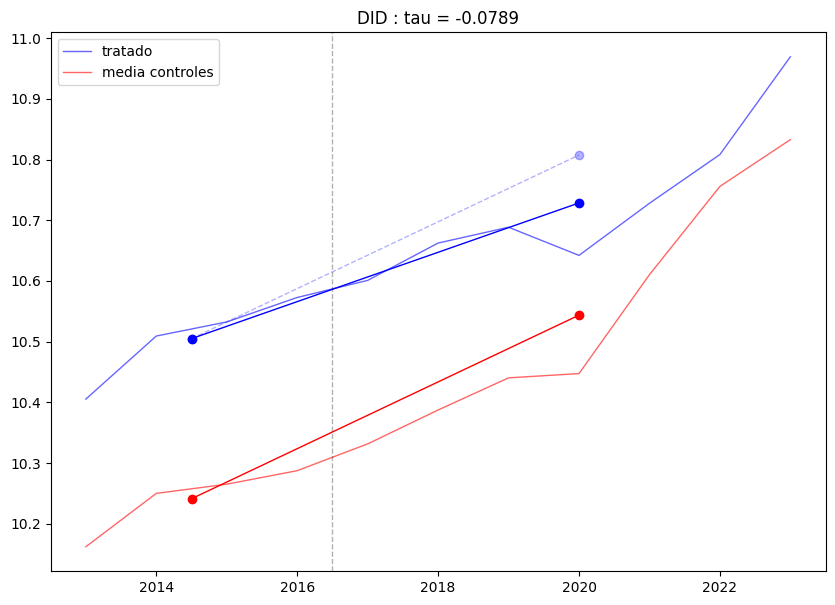

In [111]:
sdid_a.plot(model="did");  plt.show()

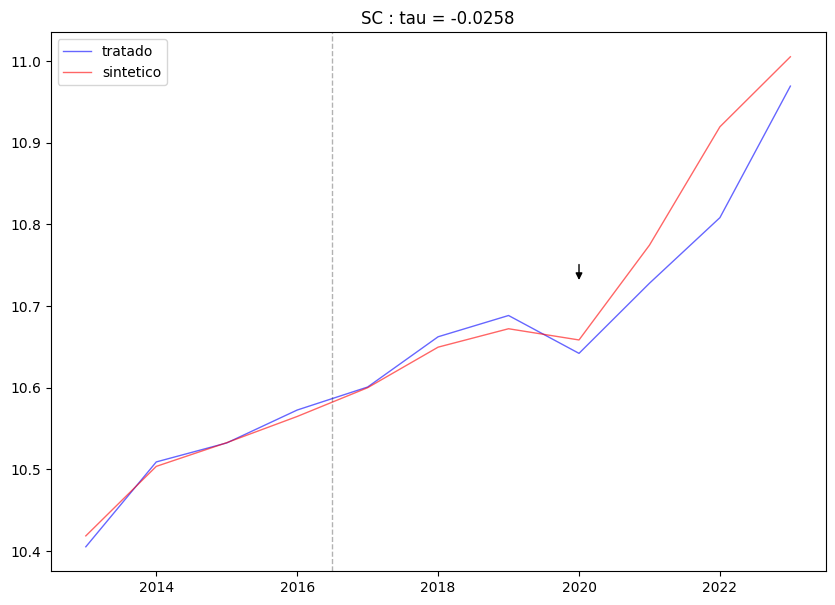

In [112]:
sdid_a.plot(model="sc");   plt.show()

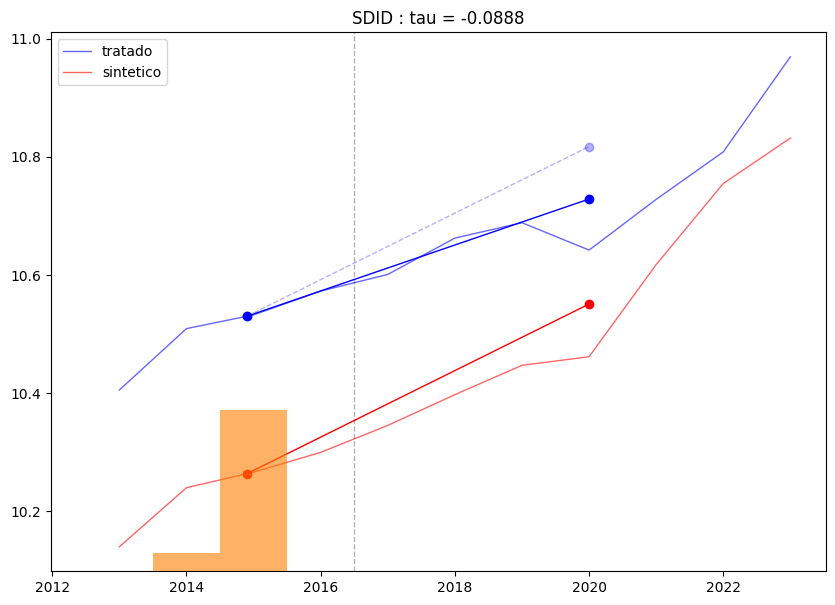

In [113]:
sdid_a.plot(model="sdid"); plt.show()

In [114]:
# Pesos do controle sintetico (SC)
omega_a = sdid_a.est_omega_ADH(sdid_a.Y_pre_c, sdid_a.Y_pre_t)
pesos_a = (
    pd.DataFrame({"Municipio": data_a.columns[data_a.columns != NOME_TRATADO],
                  "Peso SC": omega_a.flatten()})
    .query("`Peso SC` > 0.01")
    .sort_values("Peso SC", ascending=False)
    .reset_index(drop=True)
)
pesos_a


,Municipio,Peso SC
0,Itajaí,0.161179
1,Camaçari,0.104622
2,Mauá,0.050426
3,Suzano,0.037742
4,Petrópolis,0.036208
5,Betim,0.035278
6,São Bernardo do Campo,0.032935
7,Juazeiro,0.027909
8,Viamão,0.025980
9,Parnamirim,0.022617


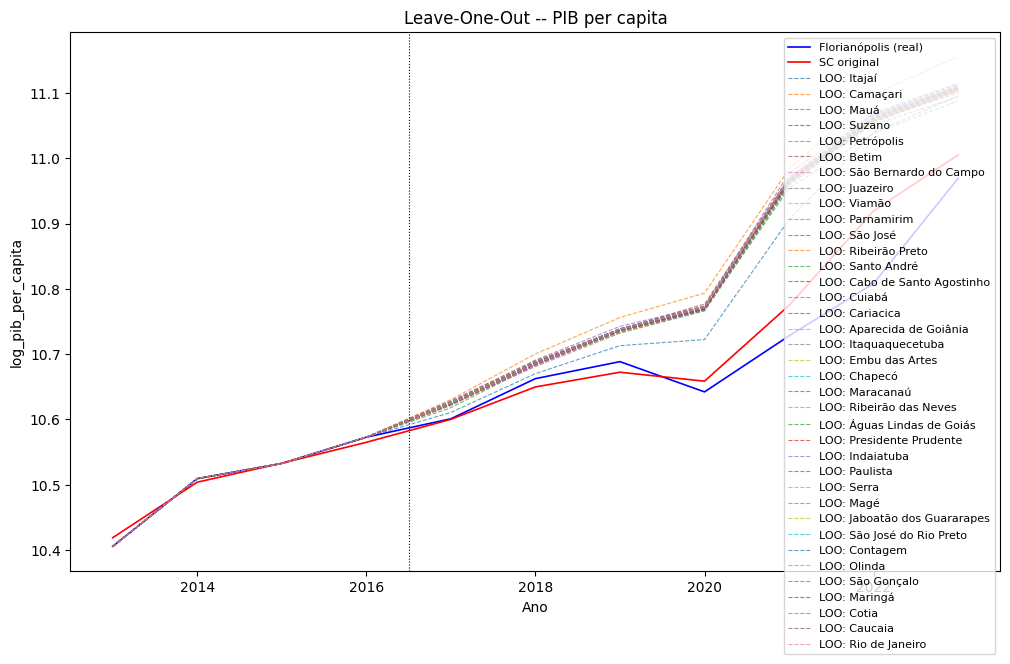

In [115]:
# Leave-One-Out: remove cada municipio com peso > 0.01 e reestima o SC
unidades_a = pesos_a["Municipio"].tolist()
sc_orig_a  = sdid_a.sc_potentical_outcome().values.flatten()
real_a     = data_a[NOME_TRATADO].values
anos_a     = np.array(data_a.index, dtype=float)

loo_a = {}
for u in unidades_a:
    _m = SynthDID(data_a.drop(columns=[u]), PRE_TERM, POST_TERM_PIB, [NOME_TRATADO])
    _m.fit(zeta_type="base")
    loo_a[u] = _m.sc_potentical_outcome().values.flatten()

plt.figure(figsize=(12, 7))
plt.plot(anos_a, real_a,    color="blue", lw=1.2, label=f"{NOME_TRATADO} (real)")
plt.plot(anos_a, sc_orig_a, color="red",  lw=1.2, label="SC original")
for u, traj in loo_a.items():
    plt.plot(anos_a, traj, ls="--", lw=0.8, alpha=0.7, label=f"LOO: {u}")
plt.axvline(x=ANO_TRATAMENTO - 0.5, color="black", ls=":", lw=0.8)
plt.xlabel("Ano"); plt.ylabel(VAR_DEP)
plt.title("Leave-One-Out -- PIB per capita")
plt.legend(fontsize=8); plt.show()


LOO mais proximo: Itajaí (RMSE=0.1244)

  Itajaí                              RMSE = 0.124390  <--
  Mauá                                RMSE = 0.139641
  Águas Lindas de Goiás               RMSE = 0.147049
  Juazeiro                            RMSE = 0.147729
  Ribeirão das Neves                  RMSE = 0.148464
  Magé                                RMSE = 0.148466
  Paulista                            RMSE = 0.148695
  Caucaia                             RMSE = 0.148707
  Cariacica                           RMSE = 0.148934
  Betim                               RMSE = 0.149259
  Indaiatuba                          RMSE = 0.149380
  Cabo de Santo Agostinho             RMSE = 0.149414
  Viamão                              RMSE = 0.149498
  Serra                               RMSE = 0.149561
  Embu das Artes                      RMSE = 0.149672
  Jaboatão dos Guararapes             RMSE = 0.149743
  Olinda                              RMSE = 0.149754
  Aparecida de Goiânia               

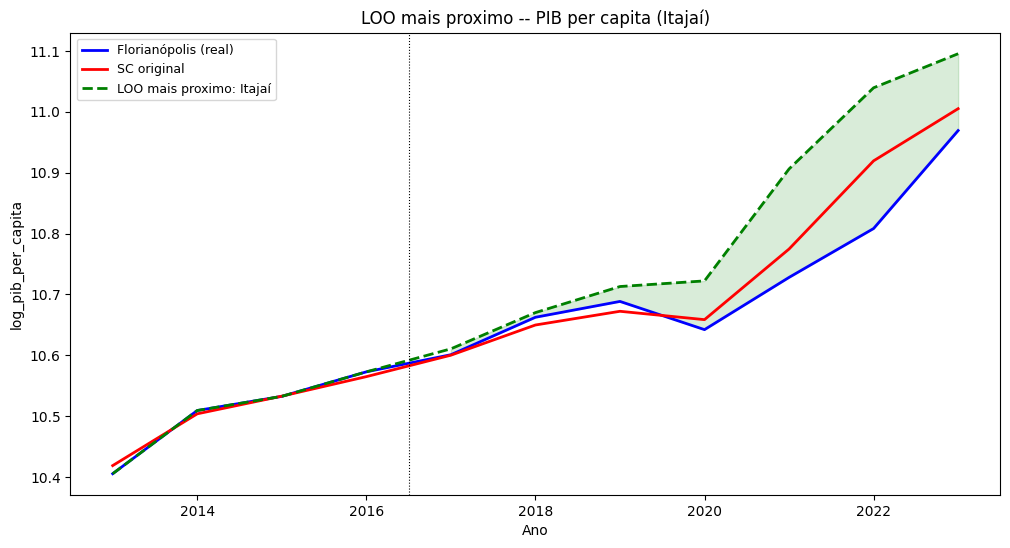

In [116]:
# LOO mais proximo da trajetoria real no pos-tratamento (menor RMSE)
_mask = anos_a >= ANO_TRATAMENTO
rmse_a = {u: np.sqrt(np.mean((t[_mask] - real_a[_mask])**2)) for u, t in loo_a.items()}
prox_a = min(rmse_a, key=rmse_a.get)
print(f"LOO mais proximo: {prox_a} (RMSE={rmse_a[prox_a]:.4f})\n")
for u, r in sorted(rmse_a.items(), key=lambda x: x[1]):
    print(f"  {u:<35} RMSE = {r:.6f}{'  <--' if u == prox_a else ''}")

plt.figure(figsize=(12, 6))
plt.plot(anos_a, real_a,        color="blue",  lw=2, label=f"{NOME_TRATADO} (real)")
plt.plot(anos_a, sc_orig_a,     color="red",   lw=2, label="SC original")
plt.plot(anos_a, loo_a[prox_a], color="green", lw=2, ls="--", label=f"LOO mais proximo: {prox_a}")
plt.fill_between(anos_a[_mask], real_a[_mask], loo_a[prox_a][_mask], color="green", alpha=0.15)
plt.axvline(x=ANO_TRATAMENTO - 0.5, color="black", ls=":", lw=0.8)
plt.xlabel("Ano"); plt.ylabel(VAR_DEP)
plt.title(f"LOO mais proximo -- PIB per capita ({prox_a})")
plt.legend(fontsize=9); plt.show()


### Event study — PIB per capita


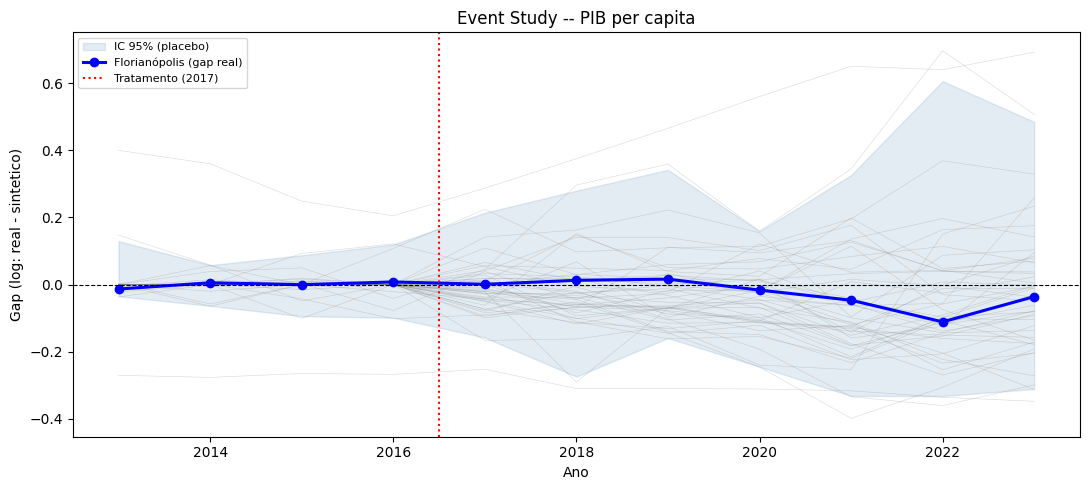

,Gap (log),"IC 2,5%","IC 97,5%",Efeito (%)
Ano,,,,
2013,-0.0133,-0.0349,0.1296,-1.3259
2014,0.0054,-0.0636,0.0580,0.5463
2015,-0.0003,-0.0944,0.0873,-0.0341
2016,0.0079,-0.0987,0.1196,0.7910
2017,0.0008,-0.1580,0.2141,0.0811
2018,0.0127,-0.2746,0.2799,1.2788
2019,0.0162,-0.1597,0.3420,1.6339
2020,-0.0164,-0.2450,0.1587,-1.6272
2021,-0.0466,-0.3321,0.3263,-4.5551


In [117]:
# Event study: gap (real - sintetico SC) ano a ano com bandas via placebo
_anos_es = np.array(data_a.index, dtype=float)
_real    = sdid_a.target_y().reindex(data_a.index).values
_sint    = sdid_a.sc_potentical_outcome().reindex(data_a.index).values
_gap_real = _real - _sint

# Gaps dos placebos: trata cada controle como se fosse o tratado
_controles_es = [c for c in data_a.columns if c != NOME_TRATADO]
_gaps_placebo = []
for _c in _controles_es:
    try:
        _m = SynthDID(data_a, PRE_TERM, POST_TERM_PIB, [_c])
        _m.fit(zeta_type="base")
        _g = (_m.target_y().reindex(data_a.index).values
              - _m.sc_potentical_outcome().reindex(data_a.index).values)
        _gaps_placebo.append(_g)
    except Exception:
        pass
_gaps_placebo = np.array(_gaps_placebo)

# Banda de confianca 95% a partir da distribuicao dos placebos por ano
_lo = np.nanpercentile(_gaps_placebo, 2.5,  axis=0)
_hi = np.nanpercentile(_gaps_placebo, 97.5, axis=0)

# Plot
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(_anos_es, _lo, _hi, color="steelblue", alpha=0.15,
                label="IC 95% (placebo)")
for _g in _gaps_placebo:
    ax.plot(_anos_es, _g, color="gray", lw=0.4, alpha=0.3)
ax.plot(_anos_es, _gap_real, color="blue", lw=2.2, marker="o",
        label=f"{NOME_TRATADO} (gap real)")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.axvline(x=ANO_TRATAMENTO - 0.5, color="red", ls=":", lw=1.5,
           label=f"Tratamento ({ANO_TRATAMENTO})")
ax.set_xlabel("Ano"); ax.set_ylabel("Gap (log: real - sintetico)")
ax.set_title("Event Study -- PIB per capita")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# Tabela do gap ano a ano com IC
display(
    pd.DataFrame({
        "Ano"      : _anos_es.astype(int),
        "Gap (log)": _gap_real,
        "IC 2,5%"  : _lo,
        "IC 97,5%" : _hi,
        "Efeito (%)": (np.exp(_gap_real) - 1) * 100,
    }).set_index("Ano").round(4)
)


In [118]:
# Significância do event study — Seção A — log PIB per capita
print("=== Seção A — log PIB per capita ===\n")
sig_es_a = teste_significancia_event_study(
    _anos_es, _gap_real, _gaps_placebo,
    ano_tratamento=ANO_TRATAMENTO, escala=100.0, unidade="%",
)

=== Seção A — log PIB per capita ===



,Período,Gap (%),p-valor,Sig.
Ano,,,,
2013,pré,-1.3347,0.1277,
2014,pré,0.5449,0.2128,
2015,pré,-0.0341,0.3617,
2016,pré,0.7879,0.1915,
2017,pós,0.0811,0.9574,
2018,pós,1.2707,0.9362,
2019,pós,1.6207,0.8936,
2020,pós,-1.6406,0.9149,
2021,pós,-4.6621,0.8723,


n placebos: 46
[Pré-tendência conjunta] RMSE pré do tratado = 0.822 % | p = 0.362  (p ALTO = ajuste pré típico; bom)
[Razão RMSPE pós/pré — Abadie 2010] razão do tratado = 5.91 | p = 0.787  (p BAIXO = efeito pós significativo)
Sig.: *** p<0.01, ** p<0.05, * p<0.10  |  p mínimo possível = 0.0213


---
## Seção B — PIB de serviços per capita


In [119]:
VAR_DEP_B = "log_pib_servicos_per_capita"

data_b = montar_painel(VAR_DEP_B, PRE_TERM[0], POST_TERM_SERV[1], rotulo="Painel B")
data_b.head()

Painel B: 9 anos x 52 municipios (51 controles) | log_pib_servicos_per_capita | janela 2013-2021 | exclusao: not_yet


,Aparecida de Goiânia,Belo Horizonte,Betim,Cabo de Santo Agostinho,Camaçari,Campo Grande,Cariacica,Caucaia,Chapecó,Contagem,...,Sete Lagoas,Suzano,São Bernardo do Campo,São Gonçalo,São José,São José do Rio Preto,Uberlândia,Viamão,Vila Velha,Águas Lindas de Goiás
2013.0,9.300041,9.991076,10.262192,9.717250,10.019754,9.606150,9.311497,8.674286,9.889316,10.062185,...,9.716137,9.465326,10.476803,8.730759,9.985177,10.119437,10.022959,8.573559,9.444589,8.067997
2014.0,9.481548,10.051303,10.279632,9.858958,10.140552,9.737396,9.519082,8.876498,9.990706,10.126657,...,9.724725,9.606212,10.452062,8.883525,10.157555,10.144234,10.131670,8.665158,9.607138,8.240224
2015.0,9.459990,10.085504,10.102203,9.841335,10.207469,9.744568,9.540541,8.933177,9.998406,10.136793,...,9.665978,9.667922,10.418254,8.967392,10.192880,10.150848,10.183283,8.754055,9.597469,8.319021
2016.0,9.462063,10.114832,10.001331,9.929300,10.150025,9.763455,9.434807,8.932844,10.035628,10.155052,...,9.616700,9.681779,10.476802,8.972876,10.277768,10.201149,10.300909,8.858930,9.612777,8.342127
2017.0,9.537499,10.131047,9.889737,10.164451,10.273822,9.838063,9.563280,9.026881,10.099484,10.260540,...,9.683658,9.688541,10.471701,8.990122,10.278092,10.241263,10.354060,8.820285,9.645251,8.430023


In [120]:
add_X_b, add_y_b = covariaveis_pre(data_b.columns, rotulo="cov B")

In [121]:
sdid_b = SynthDID(data_b, PRE_TERM, POST_TERM_SERV, [NOME_TRATADO])
sdid_b.fit(zeta_type="base", additional_X=add_X_b, additional_y=add_y_b)

var_b = sdid_b.estimate_variance(algo="placebo", replications=N_REPLICATIONS)
for modelo, v in zip(["sdid", "sc", "did"], var_b):
    att = sdid_b.hat_tau(model=modelo)
    se  = v ** 0.5
    p   = 2 * (1 - norm.cdf(abs(att / se)))
    print(f"{modelo.upper():<5} ATT={att:+.4f} ({(np.exp(att)-1)*100:+.1f}%) "
          f"SE={se:.4f}  p={p:.3f}")


100%|██████████| 200/200 [02:20<00:00,  1.42it/s]

SDID  ATT=-0.0339 (-3.3%) SE=0.0884  p=0.701
SC    ATT=+0.0004 (+0.0%) SE=0.1228  p=0.997
DID   ATT=-0.0286 (-2.8%) SE=0.1022  p=0.779


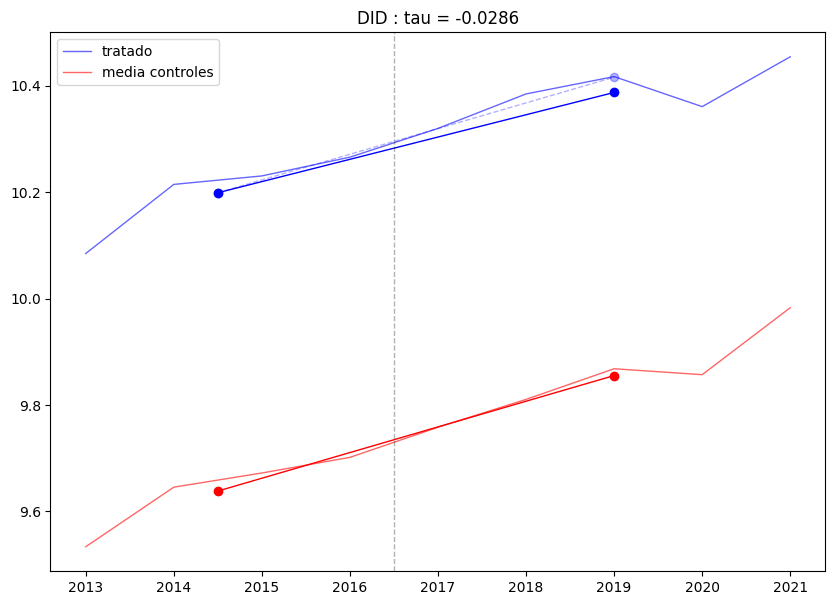

In [122]:
sdid_b.plot(model="did");  plt.show()

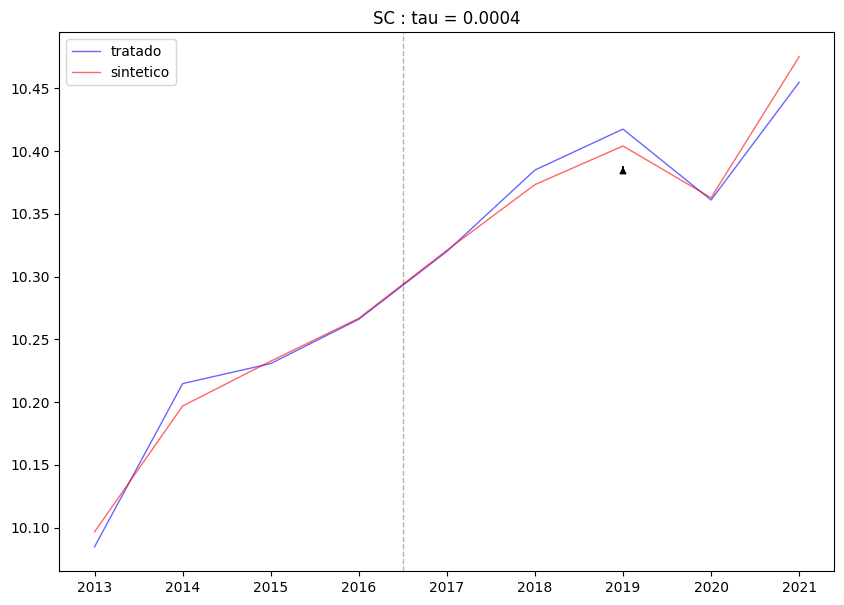

In [123]:
sdid_b.plot(model="sc");   plt.show()

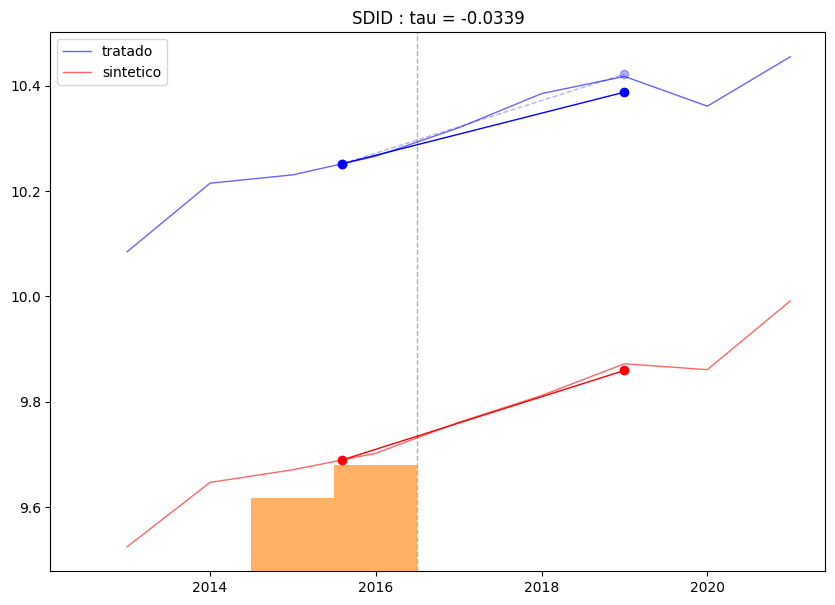

In [124]:
sdid_b.plot(model="sdid"); plt.show()

In [125]:
omega_b = sdid_b.est_omega_ADH(sdid_b.Y_pre_c, sdid_b.Y_pre_t)
pesos_b = (
    pd.DataFrame({"Municipio": data_b.columns[data_b.columns != NOME_TRATADO],
                  "Peso SC": omega_b.flatten()})
    .query("`Peso SC` > 0.01")
    .sort_values("Peso SC", ascending=False)
    .reset_index(drop=True)
)
pesos_b


,Municipio,Peso SC
0,Itajaí,0.346375
1,Embu das Artes,0.050038
2,São Bernardo do Campo,0.045617
3,São José,0.034095
4,Itaquaquecetuba,0.030994
5,Cuiabá,0.030254
6,Maracanaú,0.028266
7,Cabo de Santo Agostinho,0.025648
8,Parnamirim,0.025644
9,Ribeirão Preto,0.024141


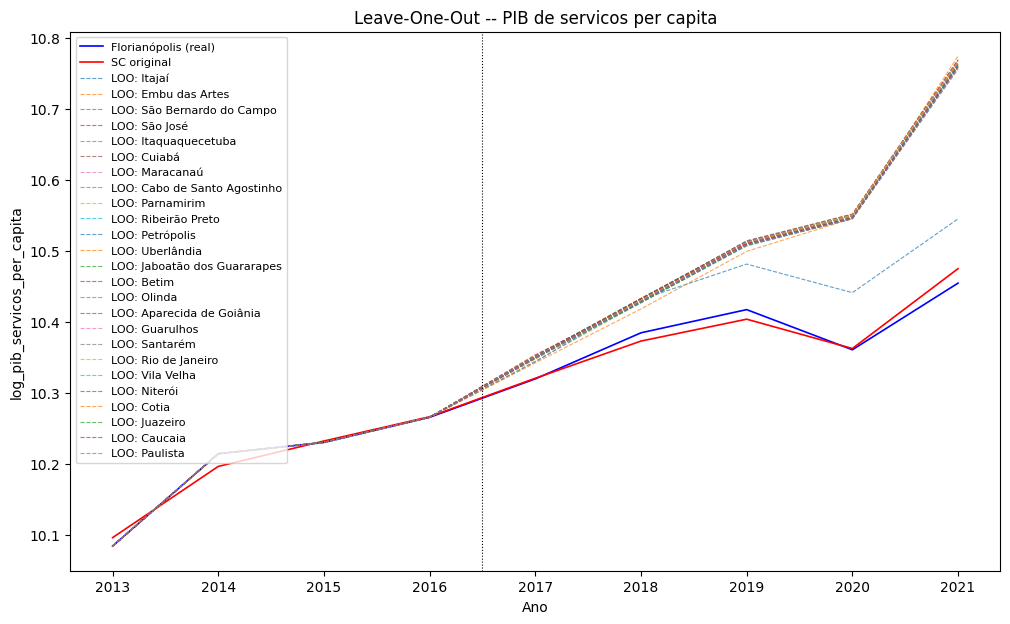

In [126]:
unidades_b = pesos_b["Municipio"].tolist()
sc_orig_b  = sdid_b.sc_potentical_outcome().values.flatten()
real_b     = data_b[NOME_TRATADO].values
anos_b     = np.array(data_b.index, dtype=float)

loo_b = {}
for u in unidades_b:
    _m = SynthDID(data_b.drop(columns=[u]), PRE_TERM, POST_TERM_SERV, [NOME_TRATADO])
    _m.fit(zeta_type="base")
    loo_b[u] = _m.sc_potentical_outcome().values.flatten()

plt.figure(figsize=(12, 7))
plt.plot(anos_b, real_b,    color="blue", lw=1.2, label=f"{NOME_TRATADO} (real)")
plt.plot(anos_b, sc_orig_b, color="red",  lw=1.2, label="SC original")
for u, traj in loo_b.items():
    plt.plot(anos_b, traj, ls="--", lw=0.8, alpha=0.7, label=f"LOO: {u}")
plt.axvline(x=ANO_TRATAMENTO - 0.5, color="black", ls=":", lw=0.8)
plt.xlabel("Ano"); plt.ylabel(VAR_DEP_B)
plt.title("Leave-One-Out -- PIB de servicos per capita")
plt.legend(fontsize=8); plt.show()


LOO mais proximo: Itajaí (RMSE=0.0656)

  Itajaí                              RMSE = 0.065586  <--
  Santarém                            RMSE = 0.164695
  Juazeiro                            RMSE = 0.165538
  Paulista                            RMSE = 0.165658
  Maracanaú                           RMSE = 0.165741
  Cabo de Santo Agostinho             RMSE = 0.166058
  Parnamirim                          RMSE = 0.166246
  Caucaia                             RMSE = 0.166984
  Niterói                             RMSE = 0.167341
  Ribeirão Preto                      RMSE = 0.167516
  Itaquaquecetuba                     RMSE = 0.167670
  Vila Velha                          RMSE = 0.168344
  São José                            RMSE = 0.168748
  São Bernardo do Campo               RMSE = 0.168784
  Olinda                              RMSE = 0.169222
  Cotia                               RMSE = 0.169481
  Rio de Janeiro                      RMSE = 0.169892
  Embu das Artes                     

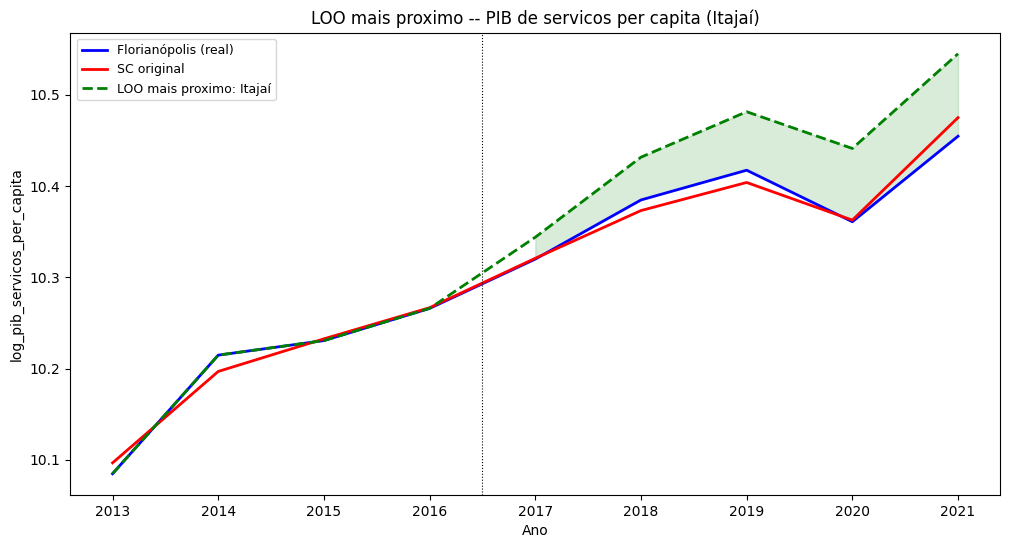

In [127]:
_mask = anos_b >= ANO_TRATAMENTO
rmse_b = {u: np.sqrt(np.mean((t[_mask] - real_b[_mask])**2)) for u, t in loo_b.items()}
prox_b = min(rmse_b, key=rmse_b.get)
print(f"LOO mais proximo: {prox_b} (RMSE={rmse_b[prox_b]:.4f})\n")
for u, r in sorted(rmse_b.items(), key=lambda x: x[1]):
    print(f"  {u:<35} RMSE = {r:.6f}{'  <--' if u == prox_b else ''}")

plt.figure(figsize=(12, 6))
plt.plot(anos_b, real_b,        color="blue",  lw=2, label=f"{NOME_TRATADO} (real)")
plt.plot(anos_b, sc_orig_b,     color="red",   lw=2, label="SC original")
plt.plot(anos_b, loo_b[prox_b], color="green", lw=2, ls="--", label=f"LOO mais proximo: {prox_b}")
plt.fill_between(anos_b[_mask], real_b[_mask], loo_b[prox_b][_mask], color="green", alpha=0.15)
plt.axvline(x=ANO_TRATAMENTO - 0.5, color="black", ls=":", lw=0.8)
plt.xlabel("Ano"); plt.ylabel(VAR_DEP_B)
plt.title(f"LOO mais proximo -- PIB de servicos per capita ({prox_b})")
plt.legend(fontsize=9); plt.show()


### Event study — PIB de serviços per capita


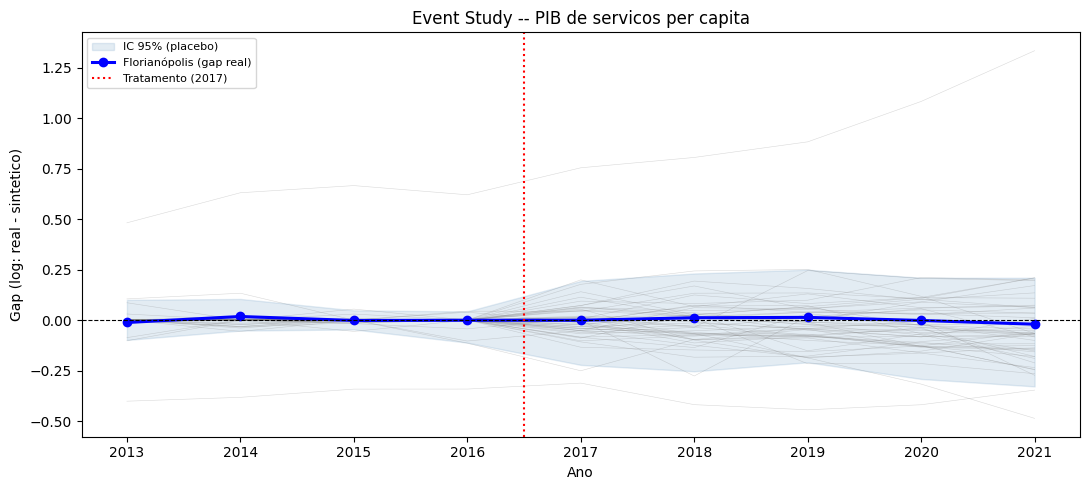

,Gap (log),"IC 2,5%","IC 97,5%",Efeito (%)
Ano,,,,
2013,-0.0119,-0.0983,0.1002,-1.1830
2014,0.0179,-0.0518,0.1047,1.8028
2015,-0.0019,-0.0463,0.0483,-0.1915
2016,-0.0008,-0.1115,0.0430,-0.0778
2017,-0.0009,-0.2218,0.1937,-0.0878
2018,0.0116,-0.2535,0.2309,1.1693
2019,0.0135,-0.2090,0.2495,1.3548
2020,-0.0018,-0.2915,0.2097,-0.1774
2021,-0.0204,-0.3283,0.2094,-2.0148


In [128]:
# Event study: gap (real - sintetico SC) ano a ano com bandas via placebo
_anos_es = np.array(data_b.index, dtype=float)
_real    = sdid_b.target_y().reindex(data_b.index).values
_sint    = sdid_b.sc_potentical_outcome().reindex(data_b.index).values
_gap_real = _real - _sint

# Gaps dos placebos: trata cada controle como se fosse o tratado
_controles_es = [c for c in data_b.columns if c != NOME_TRATADO]
_gaps_placebo = []
for _c in _controles_es:
    try:
        _m = SynthDID(data_b, PRE_TERM, POST_TERM_SERV, [_c])
        _m.fit(zeta_type="base")
        _g = (_m.target_y().reindex(data_b.index).values
              - _m.sc_potentical_outcome().reindex(data_b.index).values)
        _gaps_placebo.append(_g)
    except Exception:
        pass
_gaps_placebo = np.array(_gaps_placebo)

# Banda de confianca 95% a partir da distribuicao dos placebos por ano
_lo = np.nanpercentile(_gaps_placebo, 2.5,  axis=0)
_hi = np.nanpercentile(_gaps_placebo, 97.5, axis=0)

# Plot
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(_anos_es, _lo, _hi, color="steelblue", alpha=0.15,
                label="IC 95% (placebo)")
for _g in _gaps_placebo:
    ax.plot(_anos_es, _g, color="gray", lw=0.4, alpha=0.3)
ax.plot(_anos_es, _gap_real, color="blue", lw=2.2, marker="o",
        label=f"{NOME_TRATADO} (gap real)")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.axvline(x=ANO_TRATAMENTO - 0.5, color="red", ls=":", lw=1.5,
           label=f"Tratamento ({ANO_TRATAMENTO})")
ax.set_xlabel("Ano"); ax.set_ylabel("Gap (log: real - sintetico)")
ax.set_title("Event Study -- PIB de servicos per capita")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# Tabela do gap ano a ano com IC
display(
    pd.DataFrame({
        "Ano"      : _anos_es.astype(int),
        "Gap (log)": _gap_real,
        "IC 2,5%"  : _lo,
        "IC 97,5%" : _hi,
        "Efeito (%)": (np.exp(_gap_real) - 1) * 100,
    }).set_index("Ano").round(4)
)


In [129]:
# Significância do event study — Seção B — log PIB de serviços per capita
print("=== Seção B — log PIB de serviços per capita ===\n")
sig_es_b = teste_significancia_event_study(
    _anos_es, _gap_real, _gaps_placebo,
    ano_tratamento=ANO_TRATAMENTO, escala=100.0, unidade="%",
)

=== Seção B — log PIB de serviços per capita ===



,Período,Gap (%),p-valor,Sig.
Ano,,,,
2013,pré,-1.1901,0.1731,
2014,pré,1.7867,0.2500,
2015,pré,-0.1916,0.2885,
2016,pré,-0.0778,0.1923,
2017,pós,-0.0879,1.0000,
2018,pós,1.1626,0.9231,
2019,pós,1.3457,0.9038,
2020,pós,-0.1775,1.0000,
2021,pós,-2.0353,0.9423,


n placebos: 51
[Pré-tendência conjunta] RMSE pré do tratado = 1.078 % | p = 0.346  (p ALTO = ajuste pré típico; bom)
[Razão RMSPE pós/pré — Abadie 2010] razão do tratado = 1.12 | p = 0.962  (p BAIXO = efeito pós significativo)
Sig.: *** p<0.01, ** p<0.05, * p<0.10  |  p mínimo possível = 0.0192


---
## Pré-processamento: Taxas de Crescimento Anuais

As Seções C e D utilizam como variável dependente a **log-diferença anual**:

$$\tau_t = \ln Y_t - \ln Y_{t-1}$$

que aproxima a taxa de crescimento percentual em cada período.  
Essa especificação em **primeiras diferenças** controla por choques de nível permanentes
não capturados pelo controle sintético em nível, e testa se o tratamento alterou a
**velocidade** de crescimento de Florianópolis.

In [130]:
# ================================================================
# CÁLCULO DAS TAXAS DE CRESCIMENTO (log-diferenças anuais)
# ================================================================
df_combinado = df_combinado.sort_values(["id_municipio", "ano"]).reset_index(drop=True)

df_combinado["taxa_pib_per_capita"] = (
    df_combinado.groupby("id_municipio")["log_pib_per_capita"].diff()
)
df_combinado["taxa_pib_servicos_per_capita"] = (
    df_combinado.groupby("id_municipio")["log_pib_servicos_per_capita"].diff()
)

# Verificação
print("Obs. válidas por variável:")
print(f"  taxa_pib_per_capita           : {df_combinado['taxa_pib_per_capita'].notna().sum():,}")
print(f"  taxa_pib_servicos_per_capita  : {df_combinado['taxa_pib_servicos_per_capita'].notna().sum():,}")

print(f"\n--- Série de {NOME_TRATADO} ---")
display(
    df_combinado[df_combinado["municipio"] == NOME_TRATADO]
    [["municipio", "ano", "taxa_pib_per_capita", "taxa_pib_servicos_per_capita"]]
    .dropna(subset=["taxa_pib_per_capita"])
    .reset_index(drop=True)
)

Obs. válidas por variável:
  taxa_pib_per_capita           : 54,735
  taxa_pib_servicos_per_capita  : 43,675

--- Série de Florianópolis ---


,municipio,ano,taxa_pib_per_capita,taxa_pib_servicos_per_capita
0,Florianópolis,2014,0.103861,0.129974
1,Florianópolis,2015,0.023239,0.015964
2,Florianópolis,2016,0.040280,0.035264
3,Florianópolis,2017,0.028154,0.054046
4,Florianópolis,2018,0.061515,0.064821
5,Florianópolis,2019,0.026036,0.032614
6,Florianópolis,2020,-0.046340,-0.056488
7,Florianópolis,2021,0.085820,0.093737
8,Florianópolis,2022,0.080304,NaN
9,Florianópolis,2023,0.160981,NaN


---
## Seção C — Taxa de Crescimento do PIB per capita

**Variável dependente:** $\Delta \ln(\text{PIB}_{pc,t})$  
**Interpretação do ATT:** efeito em **pontos percentuais** sobre a taxa de crescimento anual  
**Período pré-tratamento:** 2014–2016 (primeiro ano com diff disponível a partir de 2013)  
**Período pós-tratamento:** 2017–2023

In [131]:
VAR_DEP_C   = "taxa_pib_per_capita"
PRE_TERM_C  = [2014, ANO_TRATAMENTO - 1]   # [2014, 2016]  — diff perde o ano-base
POST_TERM_C = [ANO_TRATAMENTO, 2023]        # [2017, 2023]

print(f"Variável  : {VAR_DEP_C}")
print(f"Pre C     : {PRE_TERM_C}")
print(f"Pos C     : {POST_TERM_C}")

Variável  : taxa_pib_per_capita
Pre C     : [2014, 2016]
Pos C     : [2017, 2023]


In [132]:
data_c = montar_painel(VAR_DEP_C, PRE_TERM_C[0], POST_TERM_C[1], rotulo="Painel C")
data_c

Painel C: 10 anos x 47 municipios (46 controles) | taxa_pib_per_capita | janela 2014-2023 | exclusao: not_yet


,Aparecida de Goiânia,Belo Horizonte,Betim,Cabo de Santo Agostinho,Camaçari,Cariacica,Caucaia,Chapecó,Contagem,Cotia,...,Serra,Sete Lagoas,Suzano,São Bernardo do Campo,São Gonçalo,São José,São José do Rio Preto,Viamão,Vila Velha,Águas Lindas de Goiás
2014.0,0.163409,0.054470,-0.000180,0.036139,0.175761,0.203446,0.148145,0.142871,0.073307,0.079934,...,0.106991,-0.020745,0.117552,-0.034420,0.101396,0.112779,0.025328,0.134547,0.072317,0.120684
2015.0,-0.033673,-0.003886,0.056597,0.012980,0.127696,-0.059600,0.015821,-0.022606,-0.023792,-0.007140,...,-0.004793,-0.057070,-0.130115,-0.128688,0.063218,0.026633,0.005418,0.045137,-0.002666,0.051471
2016.0,0.001041,0.008035,0.039019,0.058818,0.056577,-0.096858,-0.065393,0.027959,0.009875,0.009158,...,0.012240,-0.064271,0.139916,0.021884,0.009990,0.066573,0.028245,0.069001,-0.020923,0.029766
2017.0,0.072862,0.002361,-0.096903,0.137459,0.028566,0.071119,0.062833,0.048834,0.083057,0.045510,...,-0.002778,0.120015,0.013147,0.021319,0.013557,0.009585,0.046889,-0.011659,-0.022080,0.069436
2018.0,-0.022129,0.043773,0.085628,-0.029961,0.047371,0.184254,-0.150178,0.061981,-0.042102,0.043744,...,0.287141,0.027891,0.024796,0.122264,0.047938,0.033425,0.048124,0.079840,0.110510,0.001604
2019.0,0.022457,0.049323,0.080080,0.072728,-0.006184,0.050619,0.317694,0.072957,0.082977,0.047344,...,-0.047899,0.102129,0.069231,0.002000,-0.016718,0.045439,0.059437,0.071908,0.021669,0.042735
2020.0,0.020628,-0.000022,-0.080516,0.009045,0.046442,0.018444,0.025743,0.111111,-0.037147,0.034571,...,0.006577,-0.041109,0.035995,-0.055304,0.027986,0.004285,-0.023304,0.041927,-0.023299,0.007117
2021.0,0.150280,0.078575,0.223448,0.230774,0.263441,0.286451,0.363833,0.120748,0.202946,0.117064,...,0.383980,0.304952,0.149718,0.175507,0.060855,0.171562,0.113749,0.019168,0.243677,0.141945
2022.0,0.253977,0.174398,0.454898,0.090061,-0.080492,0.155556,-0.015760,0.018372,0.235325,0.007384,...,-0.039065,0.228030,0.116704,0.166321,0.214392,-0.019072,0.103297,0.207838,0.123169,0.120472
2023.0,0.084425,0.120808,0.096442,0.093766,-0.105376,0.297558,-0.001820,0.120719,0.056952,0.098417,...,0.079418,0.005781,0.098856,0.091817,0.114828,0.073848,0.103319,0.176512,0.150393,0.084402


In [133]:
add_X_c, add_y_c = covariaveis_pre(data_c.columns, rotulo="cov C")

In [134]:
# ── Estimação SDID / SC / DID ─────────────────────────────────────────────
sdid_c = SynthDID(data_c, PRE_TERM_C, POST_TERM_C, [NOME_TRATADO])
sdid_c.fit(zeta_type="base", additional_X=add_X_c, additional_y=add_y_c)

var_c = sdid_c.estimate_variance(algo="placebo", replications=N_REPLICATIONS)

print(f"{'Modelo':<6} {'ATT (log-dif)':>14} {'Efeito (p.p.)':>14} {'SE':>8} {'p-valor':>9}")
print("-" * 56)
for modelo, v in zip(["sdid", "sc", "did"], var_c):
    att = sdid_c.hat_tau(model=modelo)
    se  = v ** 0.5
    p   = 2 * (1 - norm.cdf(abs(att / se)))
    print(f"{modelo.upper():<6} {att:>+14.4f} {att*100:>+13.2f}     {se:.4f}  {p:.3f}")

100%|██████████| 200/200 [01:26<00:00,  2.31it/s]

Modelo  ATT (log-dif)  Efeito (p.p.)       SE   p-valor
--------------------------------------------------------
SDID          -0.0360         -3.60     0.0485  0.457
SC            -0.0077         -0.77     0.0237  0.744
DID           -0.0353         -3.53     0.0494  0.475


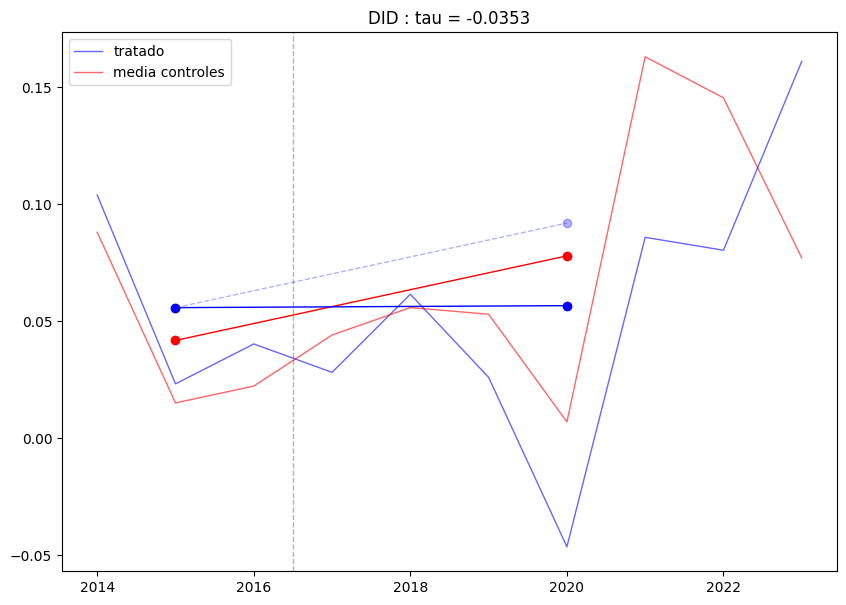

In [135]:
sdid_c.plot(model="did");  plt.show()

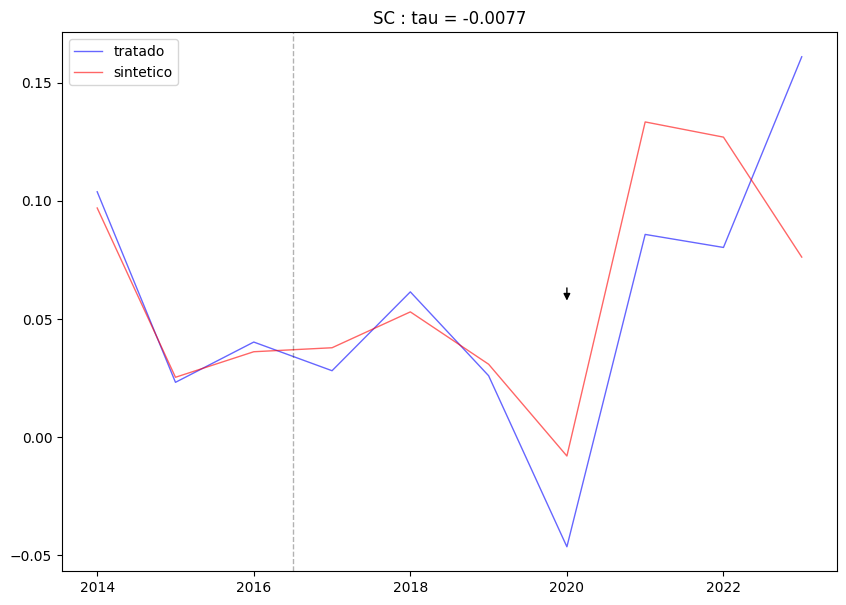

In [136]:
sdid_c.plot(model="sc");   plt.show()

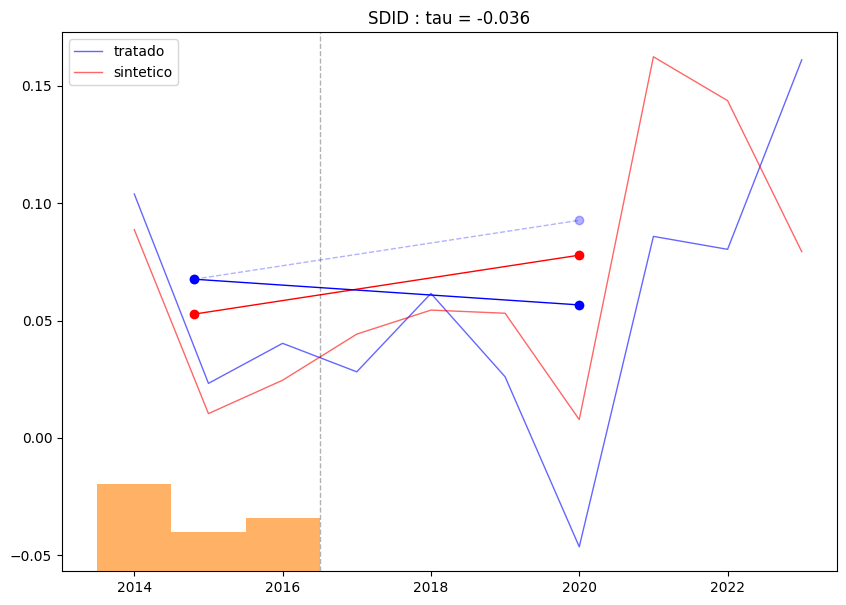

In [137]:
sdid_c.plot(model="sdid"); plt.show()

In [138]:
# ── Pesos do controle sintético ───────────────────────────────────────────
omega_c = sdid_c.est_omega_ADH(sdid_c.Y_pre_c, sdid_c.Y_pre_t)
pesos_c = (
    pd.DataFrame({
        "Municipio": data_c.columns[data_c.columns != NOME_TRATADO],
        "Peso SC"  : omega_c.flatten()
    })
    .query("`Peso SC` > 0.01")
    .sort_values("Peso SC", ascending=False)
    .reset_index(drop=True)
)
pesos_c

,Municipio,Peso SC
0,Mauá,0.060681
1,Petrópolis,0.052416
2,Camaçari,0.049704
3,Suzano,0.046880
4,Juazeiro,0.041685
5,Viamão,0.039232
6,São José,0.032464
7,Cuiabá,0.031039
8,Embu das Artes,0.030144
9,Itaquaquecetuba,0.029479


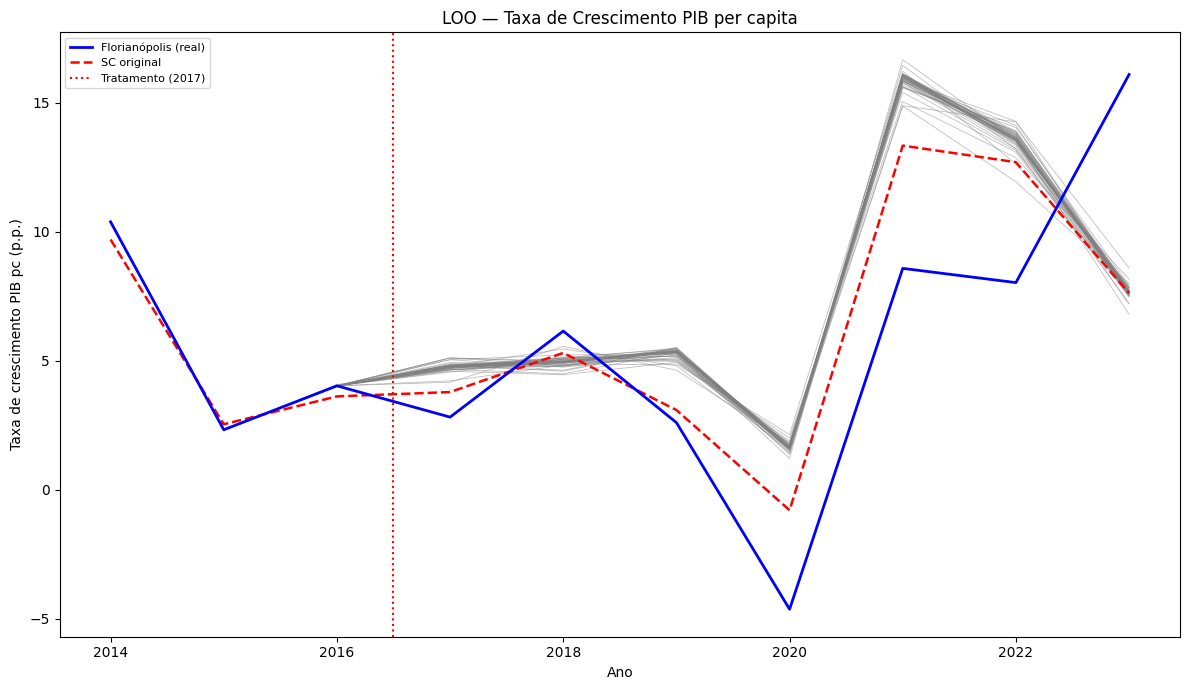

In [139]:
# ── Leave-One-Out ─────────────────────────────────────────────────────────
unidades_c = pesos_c["Municipio"].tolist()
sc_orig_c  = sdid_c.sc_potentical_outcome().values.flatten()
real_c     = data_c[NOME_TRATADO].values
anos_c     = np.array(data_c.index, dtype=float)

loo_c = {}
for u in unidades_c:
    _m = SynthDID(data_c.drop(columns=[u]), PRE_TERM_C, POST_TERM_C, [NOME_TRATADO])
    _m.fit(zeta_type="base")
    loo_c[u] = _m.sc_potentical_outcome().values.flatten()

plt.figure(figsize=(12, 7))
plt.plot(anos_c, real_c * 100,    color="blue", lw=2.0, zorder=5,
         label=f"{NOME_TRATADO} (real)")
plt.plot(anos_c, sc_orig_c * 100, color="red",  lw=1.8, ls="--", zorder=4,
         label="SC original")
for u, traj in loo_c.items():
    plt.plot(anos_c, traj * 100, color="gray", lw=0.6, alpha=0.5)
plt.axvline(x=ANO_TRATAMENTO - 0.5, color="red", ls=":", lw=1.5,
            label=f"Tratamento ({ANO_TRATAMENTO})")
plt.xlabel("Ano")
plt.ylabel("Taxa de crescimento PIB pc (p.p.)")
plt.title("LOO — Taxa de Crescimento PIB per capita")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

LOO mais próximo: Mauá (RMSE=0.0491)

  Mauá                                RMSE = 0.049078  <--
  Niterói                             RMSE = 0.051237
  Camaçari                            RMSE = 0.051781
  Itaquaquecetuba                     RMSE = 0.053377
  Parnamirim                          RMSE = 0.053390
  Caucaia                             RMSE = 0.053439
  Itajaí                              RMSE = 0.053493
  Betim                               RMSE = 0.053656
  Luziânia                            RMSE = 0.053698
  Embu das Artes                      RMSE = 0.053774
  Maracanaú                           RMSE = 0.053880
  Sete Lagoas                         RMSE = 0.054075
  Presidente Prudente                 RMSE = 0.054128
  Indaiatuba                          RMSE = 0.054193
  Contagem                            RMSE = 0.054323
  Aparecida de Goiânia                RMSE = 0.054447
  Cabo de Santo Agostinho             RMSE = 0.054477
  Maringá                             R

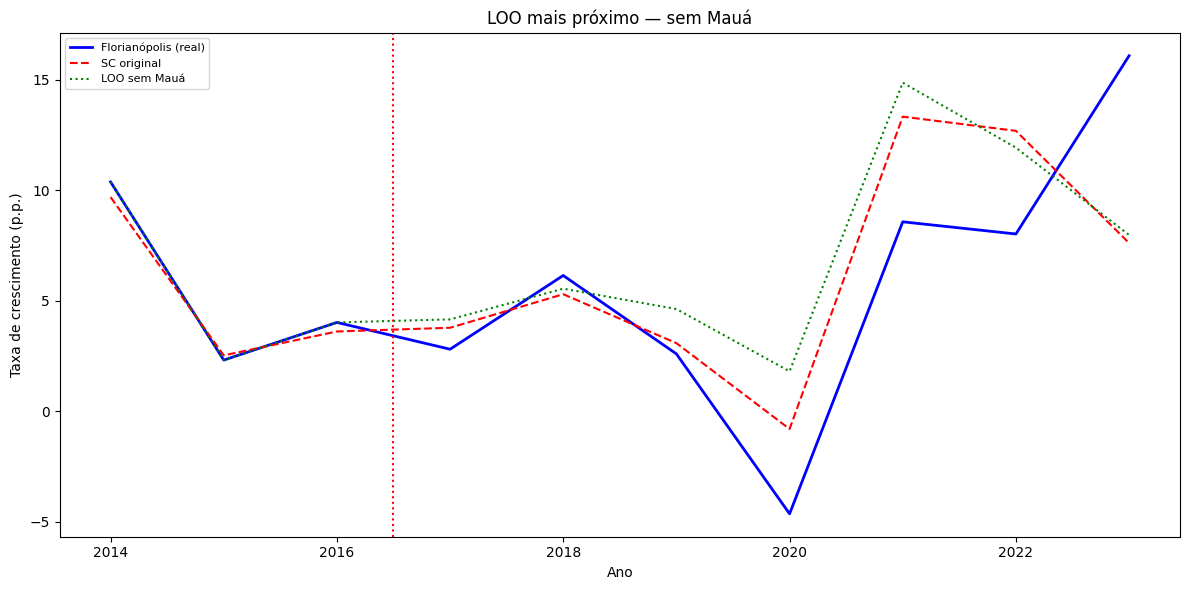

In [140]:
_mask_c = anos_c >= ANO_TRATAMENTO
rmse_c  = {u: np.sqrt(np.mean((t[_mask_c] - real_c[_mask_c])**2)) for u, t in loo_c.items()}
prox_c  = min(rmse_c, key=rmse_c.get)
print(f"LOO mais próximo: {prox_c} (RMSE={rmse_c[prox_c]:.4f})\n")
for u, r in sorted(rmse_c.items(), key=lambda x: x[1]):
    print(f"  {u:<35} RMSE = {r:.6f}{'  <--' if u == prox_c else ''}")

plt.figure(figsize=(12, 6))
plt.plot(anos_c, real_c * 100,       color="blue",  lw=2,   label=f"{NOME_TRATADO} (real)")
plt.plot(anos_c, sc_orig_c * 100,    color="red",   lw=1.5, ls="--", label="SC original")
plt.plot(anos_c, loo_c[prox_c]*100,  color="green", lw=1.5, ls=":",  label=f"LOO sem {prox_c}")
plt.axvline(x=ANO_TRATAMENTO - 0.5, color="red", ls=":", lw=1.5)
plt.xlabel("Ano"); plt.ylabel("Taxa de crescimento (p.p.)")
plt.title(f"LOO mais próximo — sem {prox_c}")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

### Event Study — Taxa de Crescimento do PIB per capita

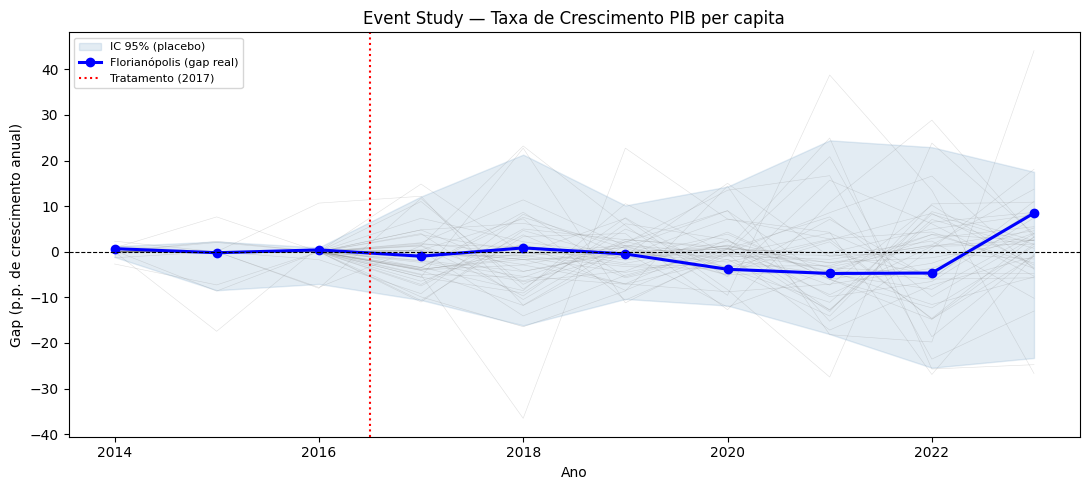

,Gap (p.p.),"IC 2,5% (p.p.)","IC 97,5% (p.p.)"
Ano,,,
2014,0.6858,-1.1507,1.1909
2015,-0.2138,-8.4423,2.2547
2016,0.4098,-7.0534,0.9457
2017,-0.9716,-10.5802,12.1098
2018,0.8469,-16.1389,21.2951
2019,-0.4862,-10.3479,10.1591
2020,-3.8399,-11.8032,14.2916
2021,-4.7592,-18.0527,24.4341
2022,-4.6680,-25.4387,22.9289


In [141]:
# ── Event study: gap ano a ano com banda de placebos ─────────────────────
_anos_es  = np.array(data_c.index, dtype=float)
_real_es  = sdid_c.target_y().reindex(data_c.index).values
_sint_es  = sdid_c.sc_potentical_outcome().reindex(data_c.index).values
_gap_real = _real_es - _sint_es

_controles_es = [c for c in data_c.columns if c != NOME_TRATADO]
_gaps_placebo = []
for _ctrl in _controles_es:
    try:
        _m = SynthDID(data_c, PRE_TERM_C, POST_TERM_C, [_ctrl])
        _m.fit(zeta_type="base")
        _g = (_m.target_y().reindex(data_c.index).values
              - _m.sc_potentical_outcome().reindex(data_c.index).values)
        _gaps_placebo.append(_g)
    except Exception:
        pass
_gaps_placebo = np.array(_gaps_placebo)

_lo = np.nanpercentile(_gaps_placebo, 2.5,  axis=0)
_hi = np.nanpercentile(_gaps_placebo, 97.5, axis=0)

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(_anos_es, _lo * 100, _hi * 100,
                color="steelblue", alpha=0.15, label="IC 95% (placebo)")
for _g in _gaps_placebo:
    ax.plot(_anos_es, _g * 100, color="gray", lw=0.4, alpha=0.25)
ax.plot(_anos_es, _gap_real * 100, color="blue", lw=2.2, marker="o",
        label=f"{NOME_TRATADO} (gap real)")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.axvline(x=ANO_TRATAMENTO - 0.5, color="red", ls=":", lw=1.5,
           label=f"Tratamento ({ANO_TRATAMENTO})")
ax.set_xlabel("Ano")
ax.set_ylabel("Gap (p.p. de crescimento anual)")
ax.set_title("Event Study — Taxa de Crescimento PIB per capita")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

display(
    pd.DataFrame({
        "Ano"             : _anos_es.astype(int),
        "Gap (p.p.)"      : _gap_real * 100,
        "IC 2,5% (p.p.)"  : _lo * 100,
        "IC 97,5% (p.p.)" : _hi * 100,
    }).set_index("Ano").round(4)
)

In [142]:
# Significância do event study — Seção C — taxa de crescimento do PIB per capita
print("=== Seção C — taxa de crescimento do PIB per capita ===\n")
sig_es_c = teste_significancia_event_study(
    _anos_es, _gap_real, _gaps_placebo,
    ano_tratamento=ANO_TRATAMENTO, escala=100.0, unidade="p.p.",
)

=== Seção C — taxa de crescimento do PIB per capita ===



,Período,Gap (p.p.),p-valor,Sig.
Ano,,,,
2014,pré,0.6858,0.1277,
2015,pré,-0.2138,0.1489,
2016,pré,0.4098,0.1277,
2017,pós,-0.9716,0.8298,
2018,pós,0.8469,0.8936,
2019,pós,-0.4862,0.9149,
2020,pós,-3.8399,0.4043,
2021,pós,-4.7592,0.5745,
2022,pós,-4.6680,0.7021,


n placebos: 46
[Pré-tendência conjunta] RMSE pré do tratado = 0.477 p.p. | p = 0.255  (p ALTO = ajuste pré típico; bom)
[Razão RMSPE pós/pré — Abadie 2010] razão do tratado = 9.13 | p = 0.766  (p BAIXO = efeito pós significativo)
Sig.: *** p<0.01, ** p<0.05, * p<0.10  |  p mínimo possível = 0.0213


---
## Seção D — Taxa de Crescimento do PIB de Serviços per capita

**Variável dependente:** $\Delta \ln(\text{PIB}_{serv,pc,t})$  
**Interpretação do ATT:** efeito em **pontos percentuais** sobre a taxa de crescimento anual  
**Período pré-tratamento:** 2014–2016  
**Período pós-tratamento:** 2017–2021 (limite do RAIS — mesmo da Seção B)

In [143]:
VAR_DEP_D   = "taxa_pib_servicos_per_capita"
PRE_TERM_D  = [2014, ANO_TRATAMENTO - 1]   # [2014, 2016]
POST_TERM_D = [ANO_TRATAMENTO, 2021]        # [2017, 2021]

print(f"Variável  : {VAR_DEP_D}")
print(f"Pre D     : {PRE_TERM_D}")
print(f"Pos D     : {POST_TERM_D}")

Variável  : taxa_pib_servicos_per_capita
Pre D     : [2014, 2016]
Pos D     : [2017, 2021]


In [144]:
data_d = montar_painel(VAR_DEP_D, PRE_TERM_D[0], POST_TERM_D[1], rotulo="Painel D")
data_d

Painel D: 8 anos x 52 municipios (51 controles) | taxa_pib_servicos_per_capita | janela 2014-2021 | exclusao: not_yet


,Aparecida de Goiânia,Belo Horizonte,Betim,Cabo de Santo Agostinho,Camaçari,Campo Grande,Cariacica,Caucaia,Chapecó,Contagem,...,Sete Lagoas,Suzano,São Bernardo do Campo,São Gonçalo,São José,São José do Rio Preto,Uberlândia,Viamão,Vila Velha,Águas Lindas de Goiás
2014.0,0.181507,0.060226,0.017440,0.141707,0.120799,0.131246,0.207585,0.202212,0.101390,0.064471,...,0.008588,0.140886,-0.024742,0.152766,0.172377,0.024796,0.108712,0.091599,0.162549,0.172228
2015.0,-0.021558,0.034202,-0.177428,-0.017622,0.066917,0.007172,0.021459,0.056679,0.007699,0.010137,...,-0.058747,0.061710,-0.033808,0.083867,0.035325,0.006614,0.051612,0.088897,-0.009669,0.078797
2016.0,0.002073,0.029328,-0.100872,0.087965,-0.057444,0.018887,-0.105735,-0.000332,0.037222,0.018259,...,-0.049277,0.013857,0.058548,0.005483,0.084888,0.050302,0.117627,0.104876,0.015307,0.023106
2017.0,0.075437,0.016215,-0.111594,0.235150,0.123796,0.074608,0.128474,0.094036,0.063856,0.105488,...,0.066958,0.006761,-0.005101,0.017246,0.000324,0.040114,0.053151,-0.038645,0.032474,0.087896
2018.0,-0.027284,0.037576,0.231247,-0.061801,0.096632,0.069319,0.149997,-0.244730,0.081498,-0.068953,...,0.070560,0.069318,0.080643,0.046505,0.060530,0.060467,-0.003172,0.057673,0.061946,-0.028670
2019.0,-0.011361,0.037957,0.070319,0.127155,0.029538,-0.001428,0.070107,0.340931,0.049834,0.084084,...,0.084004,0.075121,0.047114,-0.016513,0.058790,0.076719,0.031852,0.064892,0.052426,0.015103
2020.0,-0.019926,-0.030191,-0.100572,-0.055961,0.002548,-0.041074,0.018444,0.028662,0.102648,-0.053561,...,0.008673,0.005964,-0.051975,0.034110,0.016358,-0.040845,-0.023345,0.050587,-0.072758,0.007749
2021.0,0.202000,0.089412,0.161785,0.181521,0.128884,0.165884,0.230712,0.161704,0.148968,0.151348,...,0.135098,0.129337,0.137633,0.020991,0.185125,0.122750,0.089296,-0.079350,0.231908,0.210292


In [145]:
add_X_d, add_y_d = covariaveis_pre(data_d.columns, rotulo="cov D")

In [146]:
# ── Estimação SDID / SC / DID ─────────────────────────────────────────────
sdid_d = SynthDID(data_d, PRE_TERM_D, POST_TERM_D, [NOME_TRATADO])
sdid_d.fit(zeta_type="base", additional_X=add_X_d, additional_y=add_y_d)

var_d = sdid_d.estimate_variance(algo="placebo", replications=N_REPLICATIONS)

print(f"{'Modelo':<6} {'ATT (log-dif)':>14} {'Efeito (p.p.)':>14} {'SE':>8} {'p-valor':>9}")
print("-" * 56)
for modelo, v in zip(["sdid", "sc", "did"], var_d):
    att = sdid_d.hat_tau(model=modelo)
    se  = v ** 0.5
    p   = 2 * (1 - norm.cdf(abs(att / se)))
    print(f"{modelo.upper():<6} {att:>+14.4f} {att*100:>+13.2f}     {se:.4f}  {p:.3f}")

100%|██████████| 200/200 [01:51<00:00,  1.79it/s]

Modelo  ATT (log-dif)  Efeito (p.p.)       SE   p-valor
--------------------------------------------------------
SDID          -0.0271         -2.71     0.0517  0.600
SC            -0.0014         -0.14     0.0283  0.960
DID           -0.0229         -2.29     0.0502  0.648


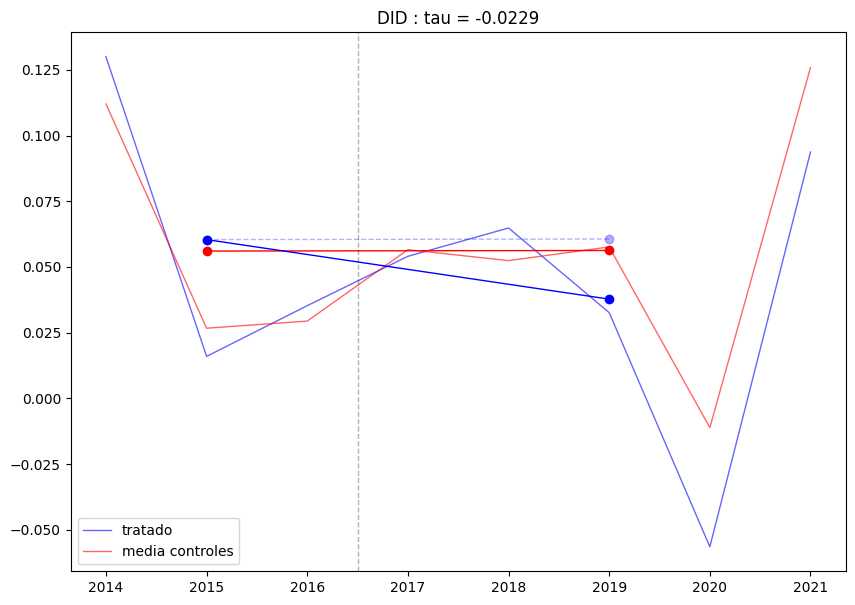

In [147]:
sdid_d.plot(model="did");  plt.show()

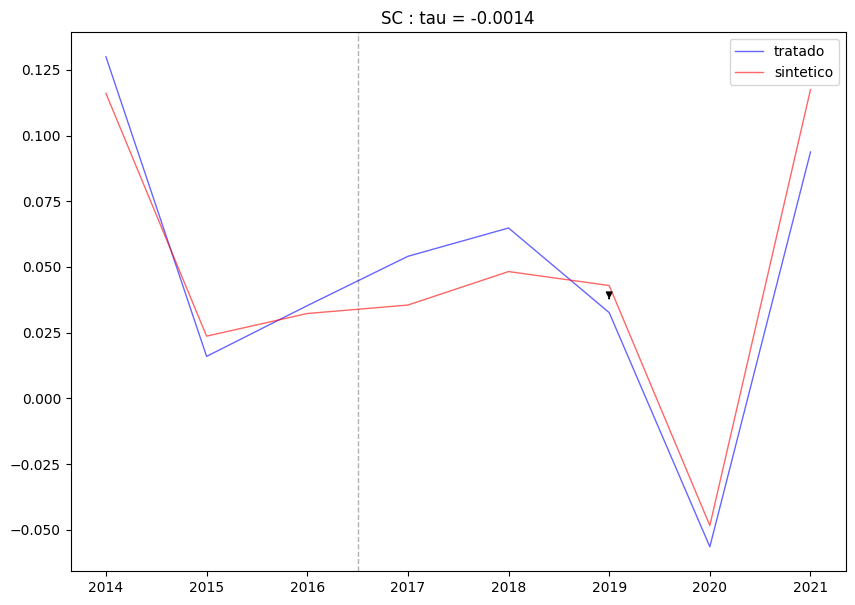

In [148]:
sdid_d.plot(model="sc");   plt.show()

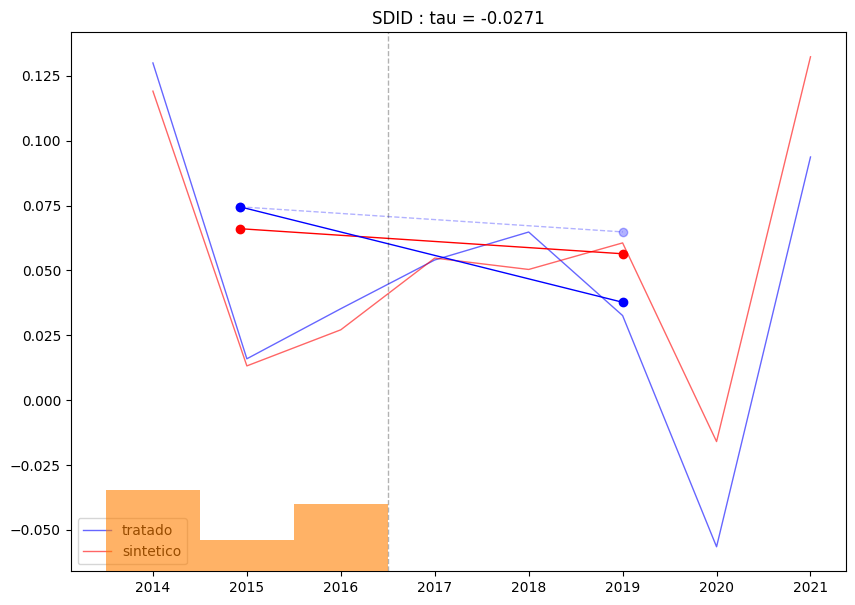

In [149]:
sdid_d.plot(model="sdid"); plt.show()

In [150]:
# ── Pesos do controle sintético ───────────────────────────────────────────
omega_d = sdid_d.est_omega_ADH(sdid_d.Y_pre_c, sdid_d.Y_pre_t)
pesos_d = (
    pd.DataFrame({
        "Municipio": data_d.columns[data_d.columns != NOME_TRATADO],
        "Peso SC"  : omega_d.flatten()
    })
    .query("`Peso SC` > 0.01")
    .sort_values("Peso SC", ascending=False)
    .reset_index(drop=True)
)
pesos_d

,Municipio,Peso SC
0,Parnamirim,0.045644
1,Jaboatão dos Guararapes,0.043929
2,Olinda,0.042881
3,Aparecida de Goiânia,0.041375
4,Embu das Artes,0.040307
5,Cabo de Santo Agostinho,0.039801
6,Vila Velha,0.033093
7,Guarulhos,0.033077
8,Betim,0.033058
9,Cuiabá,0.029766


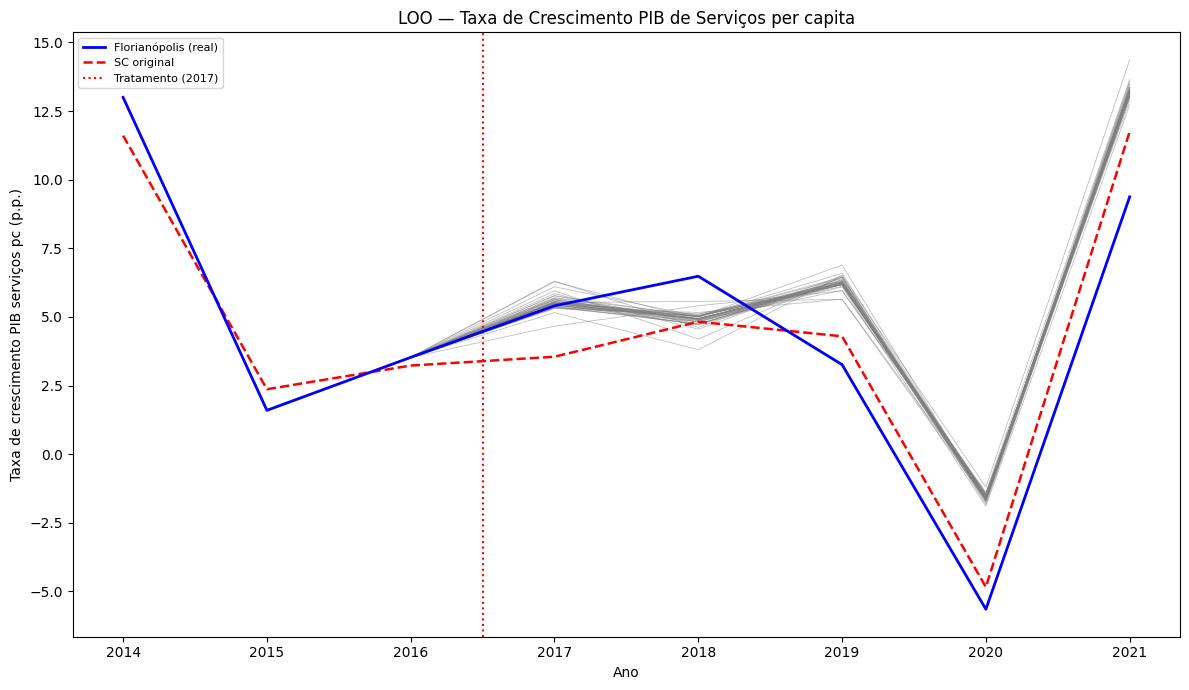

In [151]:
# ── Leave-One-Out ─────────────────────────────────────────────────────────
unidades_d = pesos_d["Municipio"].tolist()
sc_orig_d  = sdid_d.sc_potentical_outcome().values.flatten()
real_d     = data_d[NOME_TRATADO].values
anos_d     = np.array(data_d.index, dtype=float)

loo_d = {}
for u in unidades_d:
    _m = SynthDID(data_d.drop(columns=[u]), PRE_TERM_D, POST_TERM_D, [NOME_TRATADO])
    _m.fit(zeta_type="base")
    loo_d[u] = _m.sc_potentical_outcome().values.flatten()

plt.figure(figsize=(12, 7))
plt.plot(anos_d, real_d * 100,    color="blue", lw=2.0, zorder=5,
         label=f"{NOME_TRATADO} (real)")
plt.plot(anos_d, sc_orig_d * 100, color="red",  lw=1.8, ls="--", zorder=4,
         label="SC original")
for u, traj in loo_d.items():
    plt.plot(anos_d, traj * 100, color="gray", lw=0.6, alpha=0.5)
plt.axvline(x=ANO_TRATAMENTO - 0.5, color="red", ls=":", lw=1.5,
            label=f"Tratamento ({ANO_TRATAMENTO})")
plt.xlabel("Ano")
plt.ylabel("Taxa de crescimento PIB serviços pc (p.p.)")
plt.title("LOO — Taxa de Crescimento PIB de Serviços per capita")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

LOO mais próximo: Itajaí (RMSE=0.0269)

  Itajaí                              RMSE = 0.026864  <--
  Caucaia                             RMSE = 0.027372
  Paulista                            RMSE = 0.028093
  Cabo de Santo Agostinho             RMSE = 0.028313
  Cariacica                           RMSE = 0.028339
  Chapecó                             RMSE = 0.028351
  Diadema                             RMSE = 0.028633
  Mauá                                RMSE = 0.028699
  Águas Lindas de Goiás               RMSE = 0.028739
  São José                            RMSE = 0.028769
  Vila Velha                          RMSE = 0.028870
  Cotia                               RMSE = 0.028872
  Ribeirão Preto                      RMSE = 0.028897
  Macapá                              RMSE = 0.028920
  Suzano                              RMSE = 0.028924
  Camaçari                            RMSE = 0.028927
  Parnamirim                          RMSE = 0.028947
  Mogi das Cruzes                    

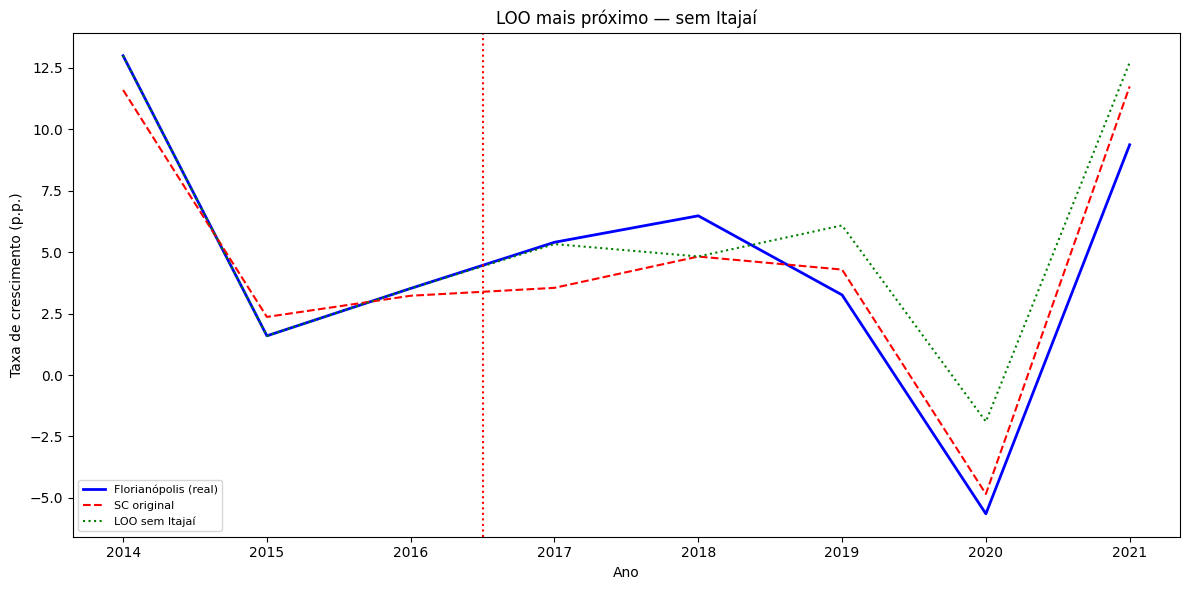

In [152]:
_mask_d = anos_d >= ANO_TRATAMENTO
rmse_d  = {u: np.sqrt(np.mean((t[_mask_d] - real_d[_mask_d])**2)) for u, t in loo_d.items()}
prox_d  = min(rmse_d, key=rmse_d.get)
print(f"LOO mais próximo: {prox_d} (RMSE={rmse_d[prox_d]:.4f})\n")
for u, r in sorted(rmse_d.items(), key=lambda x: x[1]):
    print(f"  {u:<35} RMSE = {r:.6f}{'  <--' if u == prox_d else ''}")

plt.figure(figsize=(12, 6))
plt.plot(anos_d, real_d * 100,       color="blue",  lw=2,   label=f"{NOME_TRATADO} (real)")
plt.plot(anos_d, sc_orig_d * 100,    color="red",   lw=1.5, ls="--", label="SC original")
plt.plot(anos_d, loo_d[prox_d]*100,  color="green", lw=1.5, ls=":",  label=f"LOO sem {prox_d}")
plt.axvline(x=ANO_TRATAMENTO - 0.5, color="red", ls=":", lw=1.5)
plt.xlabel("Ano"); plt.ylabel("Taxa de crescimento (p.p.)")
plt.title(f"LOO mais próximo — sem {prox_d}")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

### Event Study — Taxa de Crescimento do PIB de Serviços per capita

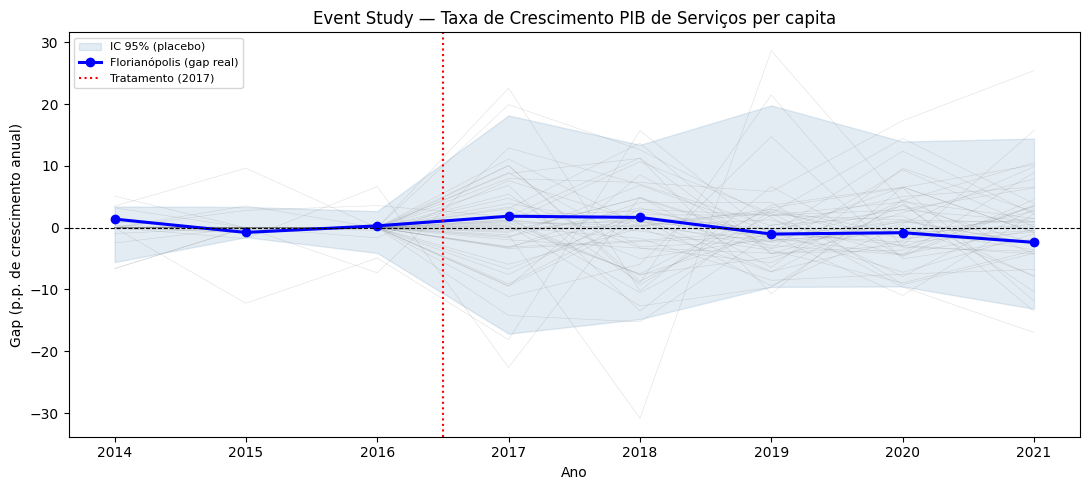

,Gap (p.p.),"IC 2,5% (p.p.)","IC 97,5% (p.p.)"
Ano,,,
2014,1.3945,-5.5699,3.4161
2015,-0.7698,-1.5377,3.3521
2016,0.2985,-4.0894,2.6771
2017,1.8549,-17.1507,18.1532
2018,1.6578,-14.7903,13.4044
2019,-1.0312,-9.5831,19.7856
2020,-0.8082,-9.5095,13.9396
2021,-2.3751,-13.1233,14.4156


In [153]:
# ── Event study: gap ano a ano com banda de placebos ─────────────────────
_anos_es  = np.array(data_d.index, dtype=float)
_real_es  = sdid_d.target_y().reindex(data_d.index).values
_sint_es  = sdid_d.sc_potentical_outcome().reindex(data_d.index).values
_gap_real = _real_es - _sint_es

_controles_es = [c for c in data_d.columns if c != NOME_TRATADO]
_gaps_placebo = []
for _ctrl in _controles_es:
    try:
        _m = SynthDID(data_d, PRE_TERM_D, POST_TERM_D, [_ctrl])
        _m.fit(zeta_type="base")
        _g = (_m.target_y().reindex(data_d.index).values
              - _m.sc_potentical_outcome().reindex(data_d.index).values)
        _gaps_placebo.append(_g)
    except Exception:
        pass
_gaps_placebo = np.array(_gaps_placebo)

_lo = np.nanpercentile(_gaps_placebo, 2.5,  axis=0)
_hi = np.nanpercentile(_gaps_placebo, 97.5, axis=0)

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(_anos_es, _lo * 100, _hi * 100,
                color="steelblue", alpha=0.15, label="IC 95% (placebo)")
for _g in _gaps_placebo:
    ax.plot(_anos_es, _g * 100, color="gray", lw=0.4, alpha=0.25)
ax.plot(_anos_es, _gap_real * 100, color="blue", lw=2.2, marker="o",
        label=f"{NOME_TRATADO} (gap real)")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.axvline(x=ANO_TRATAMENTO - 0.5, color="red", ls=":", lw=1.5,
           label=f"Tratamento ({ANO_TRATAMENTO})")
ax.set_xlabel("Ano")
ax.set_ylabel("Gap (p.p. de crescimento anual)")
ax.set_title("Event Study — Taxa de Crescimento PIB de Serviços per capita")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

display(
    pd.DataFrame({
        "Ano"             : _anos_es.astype(int),
        "Gap (p.p.)"      : _gap_real * 100,
        "IC 2,5% (p.p.)"  : _lo * 100,
        "IC 97,5% (p.p.)" : _hi * 100,
    }).set_index("Ano").round(4)
)

In [154]:
# Significância do event study — Seção D — taxa de crescimento do PIB de serviços
print("=== Seção D — taxa de crescimento do PIB de serviços ===\n")
sig_es_d = teste_significancia_event_study(
    _anos_es, _gap_real, _gaps_placebo,
    ano_tratamento=ANO_TRATAMENTO, escala=100.0, unidade="p.p.",
)

=== Seção D — taxa de crescimento do PIB de serviços ===



,Período,Gap (p.p.),p-valor,Sig.
Ano,,,,
2014,pré,1.3945,0.1346,
2015,pré,-0.7698,0.1346,
2016,pré,0.2985,0.1346,
2017,pós,1.8549,0.6538,
2018,pós,1.6578,0.8077,
2019,pós,-1.0312,0.8269,
2020,pós,-0.8082,0.9231,
2021,pós,-2.3751,0.6538,


n placebos: 51
[Pré-tendência conjunta] RMSE pré do tratado = 0.936 p.p. | p = 0.231  (p ALTO = ajuste pré típico; bom)
[Razão RMSPE pós/pré — Abadie 2010] razão do tratado = 1.76 | p = 0.904  (p BAIXO = efeito pós significativo)
Sig.: *** p<0.01, ** p<0.05, * p<0.10  |  p mínimo possível = 0.0192


---
## Seção E — SynthDID Escalonado (por coorte de adoção)

**Desenho.** Seguindo a extensão de Arkhangelsky et al. (2021) para adoção escalonada,
estima-se um **SynthDID separado por coorte** de concessão ANAC e agrega-se o ATT com
pesos proporcionais ao número de observações tratadas pós-tratamento de cada coorte:

$$\hat{\tau} = \sum_g w_g\,\hat{\tau}_g, \qquad w_g = \frac{N_g \times T^{post}_g}{\sum_h N_h \times T^{post}_h}$$

**Coortes (ano do leilão):** 2017 (4ª rodada), 2019 (5ª), 2021 (6ª), 2022 (7ª).

**Controles:** apenas municípios **nunca tratados** (pool sem qualquer sede de aeroporto
concedido). Como cada coorte tem pós-período que avança até o fim da amostra, os
ainda-não-tratados não podem servir de controle aqui sem contaminar o pós — por isso o
grupo limpo é o nunca-tratado.

**Detalhe de implementação.** O pacote `synthdid` tem um bug no `hat_tau` com múltiplas
unidades tratadas (usa apenas a primeira no termo pré). Por isso, cada coorte é colapsada
em uma **coluna-média dos seus municípios** antes do fit — equivalente ao tratamento do
caso multi-unidade no paper original, e que mantém o pacote no seu caminho de código
testado (tratado único). O ATT resultante é o efeito médio sobre o log-desfecho da coorte.

**Nota:** as covariáveis (`USAR_COVARIAVEIS`) não são usadas nesta seção — cada coorte
teria janela pré própria, e a comparabilidade entre coortes ficaria comprometida.

In [155]:
# ================================================================
# SETUP DO SYNTHDID ESCALONADO
# Coortes, controles nunca-tratados e função auxiliar por coorte.
# ================================================================

COORTES = {
    2017: list(round4.values()),
    2019: list(round5.values()),
    2021: list(round6.values()),
    2022: list(round7.values()),
}

# Controles: pool SEM qualquer tratado (nunca-tratados), independente da flag
_nunca_tratados = [c for c in pd.Index(codigos_pool)
                   if c not in set(treated_after_round4)]
print(f"Controles nunca-tratados disponíveis: {len(_nunca_tratados)}")

N_REPLICATIONS_E = N_REPLICATIONS   # réplicas do placebo por coorte


def sdid_coorte(var_dep, ano_coorte, cods_tratados, ano_ini, ano_fim,
                replications=N_REPLICATIONS_E):
    """Roda um SynthDID para uma coorte: tratados colapsados em coluna-média,
    controles nunca-tratados, pre=[ano_ini, coorte-1], post=[coorte, ano_fim].
    Retorna dict com ATT, SE, contagens — ou None se a coorte for inviável."""
    if ano_coorte > ano_fim:
        return None   # coorte sem período pós na janela

    ids = set(_nunca_tratados) | set(cods_tratados)
    _df = (
        df_combinado[
            df_combinado["id_municipio"].isin(ids) &
            df_combinado["ano"].between(ano_ini, ano_fim)
        ][["id_municipio", "municipio", "ano", var_dep]]
        .dropna(subset=[var_dep])
    )

    # balanceamento na janela
    _anos = set(range(ano_ini, ano_fim + 1))
    _ok = _df.groupby("municipio")["ano"].apply(lambda s: _anos.issubset(set(s)))
    _df = _df[_df["municipio"].isin(_ok[_ok].index)]

    wide = _df.pivot_table(index="ano", columns="municipio", values=var_dep)
    wide.index = np.array(wide.index, dtype=np.float64)
    wide.columns.name = None

    nomes_trat = (
        _df[_df["id_municipio"].isin(cods_tratados)]["municipio"].unique().tolist()
    )
    nomes_trat = [n for n in nomes_trat if n in wide.columns]
    if len(nomes_trat) == 0:
        return None

    # colapsar coorte em coluna-média e manter só controles + coorte
    nomes_ctrl = [c for c in wide.columns if c not in nomes_trat]
    w = wide[nomes_ctrl].copy()
    label = f"COORTE_{ano_coorte}"
    w[label] = wide[nomes_trat].mean(axis=1)

    pre, post = [ano_ini, ano_coorte - 1], [ano_coorte, ano_fim]
    m = SynthDID(w, pre, post, [label])
    m.fit(zeta_type="base")

    var = m.estimate_variance(algo="placebo", replications=replications)
    out = {"coorte": ano_coorte, "n_tratados": len(nomes_trat),
           "t_pos": ano_fim - ano_coorte + 1, "n_controles": len(nomes_ctrl),
           "tratados": nomes_trat, "modelo": m}
    for mod, v in zip(["sdid", "sc", "did"], var):
        out[f"att_{mod}"] = m.hat_tau(model=mod)
        out[f"se_{mod}"]  = v ** 0.5
    return out


def agrega_coortes(resultados, modelo="sdid"):
    """ATT agregado com pesos w_g = N_g * T_pos_g; SE assume independência entre coortes."""
    rs = [r for r in resultados if r is not None]
    pesos = np.array([r["n_tratados"] * r["t_pos"] for r in rs], dtype=float)
    pesos /= pesos.sum()
    att = float(np.sum([w * r[f"att_{modelo}"] for w, r in zip(pesos, rs)]))
    se  = float(np.sqrt(np.sum([(w * r[f"se_{modelo}"]) ** 2 for w, r in zip(pesos, rs)])))
    return att, se, pesos

Controles nunca-tratados disponíveis: 48


### E.1 — SynthDID escalonado: log PIB per capita (2013–2023)

In [156]:
VAR_E1 = "log_pib_per_capita"
res_e1 = []
for _g, _cods in COORTES.items():
    print(f"Coorte {_g}...", end=" ")
    _r = sdid_coorte(VAR_E1, _g, _cods, 2013, 2023)
    res_e1.append(_r)
    print("ok" if _r else "sem pós-período — pulada")

tab_e1 = pd.DataFrame([
    {"Coorte": r["coorte"], "N tratados": r["n_tratados"], "T pós": r["t_pos"],
     "N controles": r["n_controles"],
     "ATT SDID": r["att_sdid"], "SE": r["se_sdid"],
     "p-valor": 2 * (1 - norm.cdf(abs(r["att_sdid"] / r["se_sdid"]))),
     "ATT SC": r["att_sc"], "ATT DID": r["att_did"]}
    for r in res_e1 if r is not None
]).set_index("Coorte").round(4)
display(tab_e1)

att_agg, se_agg, pesos_agg = agrega_coortes(res_e1, "sdid")
p_agg = 2 * (1 - norm.cdf(abs(att_agg / se_agg)))
print(f"\n=== ATT AGREGADO (SDID escalonado) ===")
print(f"ATT = {att_agg:+.4f} ({att_agg*100:+.2f}%)  SE = {se_agg:.4f}  p = {p_agg:.3f}")
print(f"Pesos por coorte: "
      + ", ".join(f"{r['coorte']}: {w:.2f}"
                  for r, w in zip([x for x in res_e1 if x], pesos_agg)))

Coorte 2017... 

100%|██████████| 200/200 [02:11<00:00,  1.52it/s]


ok
Coorte 2019... 

100%|██████████| 200/200 [02:03<00:00,  1.61it/s]


ok
Coorte 2021... 

...

ok
Coorte 2022... 

100%|██████████| 200/200 [02:32<00:00,  1.31it/s]


ok


,N tratados,T pós,N controles,ATT SDID,SE,p-valor,ATT SC,ATT DID
Coorte,,,,,,,,
2017,4,7,46,-0.0754,0.1088,0.4880,-0.0855,-0.0741
2019,11,5,46,-0.0420,0.0975,0.6668,-0.0460,-0.0441
2021,19,3,46,-0.0602,0.1026,0.5573,-0.0681,-0.0595
2022,13,2,46,-0.0675,0.1198,0.5732,-0.0975,-0.0758



=== ATT AGREGADO (SDID escalonado) ===
ATT = -0.0579 (-5.79%)  SE = 0.0545  p = 0.289
Pesos por coorte: 2017: 0.17, 2019: 0.33, 2021: 0.34, 2022: 0.16


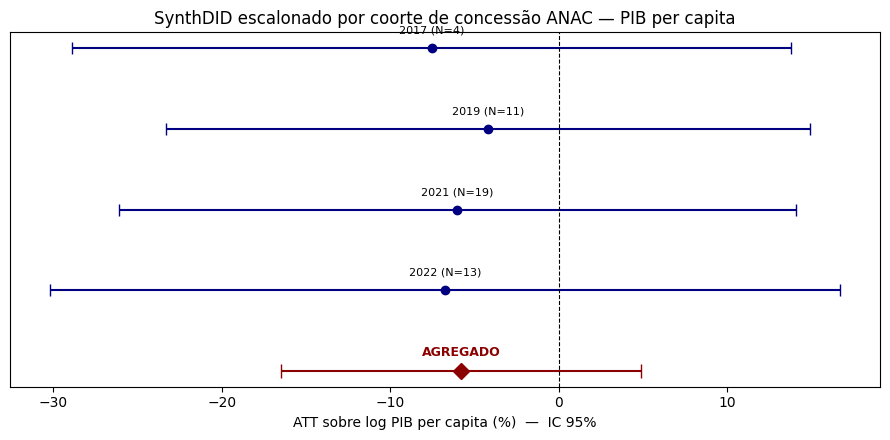

In [157]:
# Forest plot: ATT por coorte + agregado
_rs = [r for r in res_e1 if r is not None]
_y = np.arange(len(_rs), 0, -1)

plt.figure(figsize=(9, 4.5))
for yi, r in zip(_y, _rs):
    att, se = r["att_sdid"] * 100, r["se_sdid"] * 100
    plt.errorbar(att, yi, xerr=1.96 * se, fmt="o", color="navy", capsize=4)
    plt.text(att, yi + 0.18, f"{r['coorte']} (N={r['n_tratados']})",
             ha="center", fontsize=8)
plt.errorbar(att_agg * 100, 0, xerr=1.96 * se_agg * 100,
             fmt="D", color="darkred", capsize=5, markersize=8)
plt.text(att_agg * 100, 0.18, "AGREGADO", ha="center", fontsize=9,
         fontweight="bold", color="darkred")
plt.axvline(0, color="black", lw=0.8, ls="--")
plt.yticks([])
plt.xlabel("ATT sobre log PIB per capita (%)  —  IC 95%")
plt.title("SynthDID escalonado por coorte de concessão ANAC — PIB per capita")
plt.tight_layout(); plt.show()


Coorte 2017 — tratados: Fortaleza, Salvador, Florianópolis, Porto Alegre


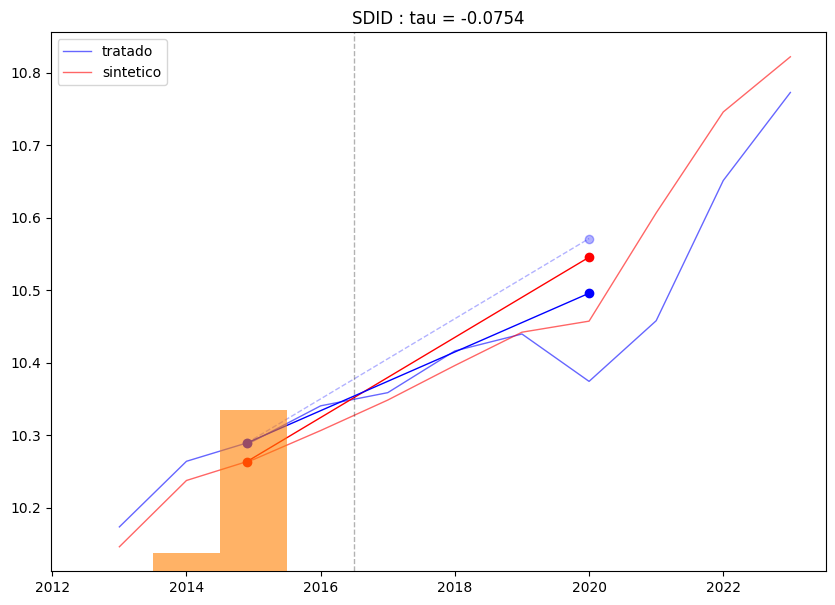


Coorte 2019 — tratados: Juazeiro do Norte, Campina Grande, João Pessoa, Recife, Maceió, Aracaju, Vitória, Alta Floresta, Rondonópolis, Sinop, Várzea Grande


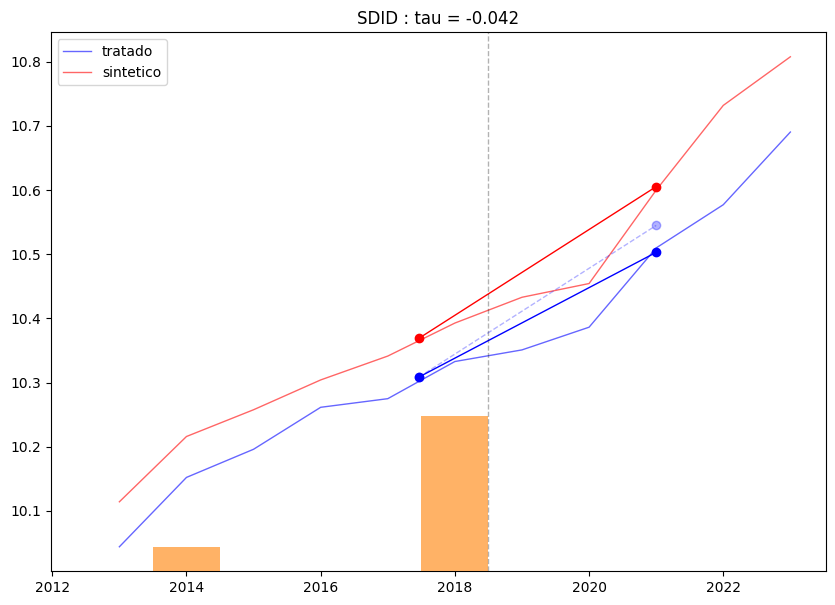


Coorte 2021 — tratados: Cruzeiro do Sul, Rio Branco, Manaus, Tonantins, Boa Vista, Palmas, Imperatriz, São Luís, Teresina, Petrolina, Curitiba, Foz do Iguaçu, Londrina, São José dos Pinhais, Joinville, Bagé, Pelotas, Uruguaiana, Goiânia


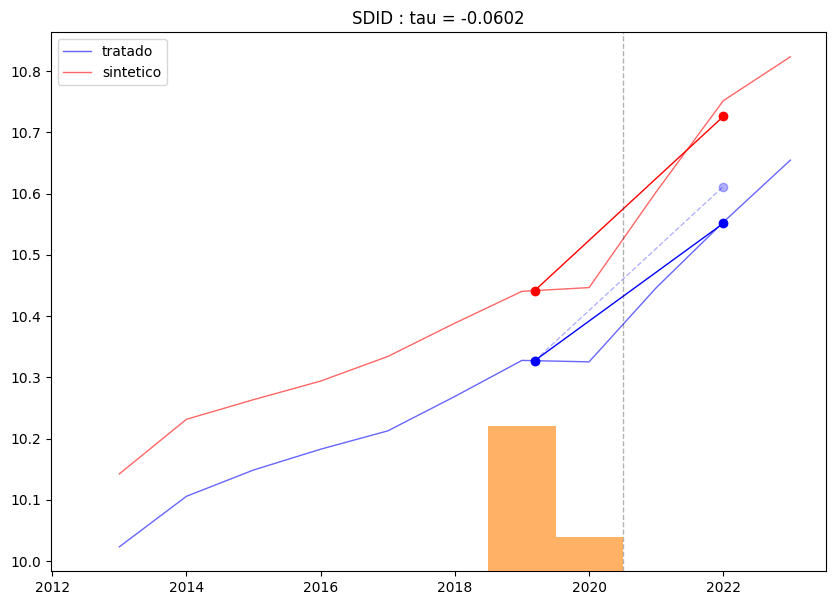


Coorte 2022 — tratados: Altamira, Belém, Marabá, Parauapebas, Santarém, Macapá, Montes Claros, Uberaba, Uberlândia, São Paulo, Campo Grande, Corumbá, Ponta Porã


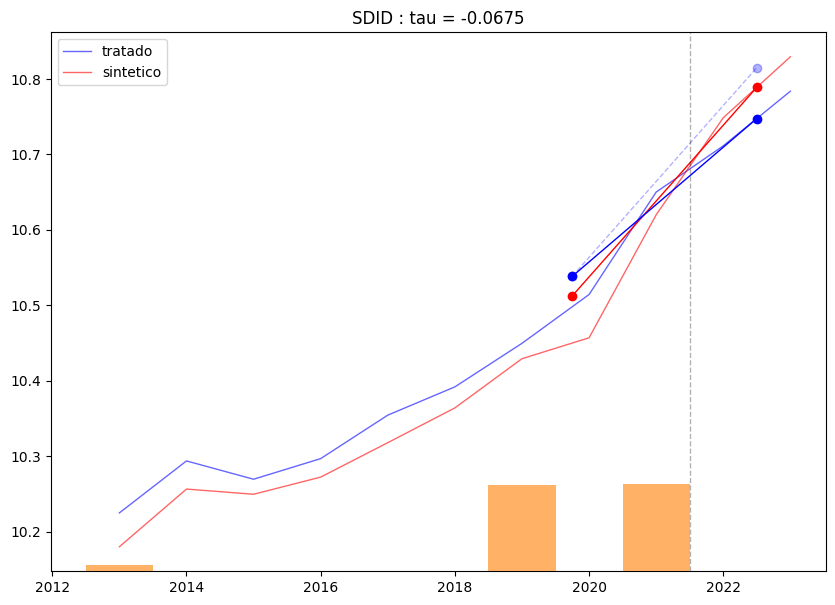

In [158]:
# Trajetórias SDID por coorte (tratado médio vs sintético)
for r in [x for x in res_e1 if x is not None]:
    print(f"\nCoorte {r['coorte']} — tratados: {', '.join(r['tratados'])}")
    r["modelo"].plot(model="sdid")
    plt.show()

### E.2 — SynthDID escalonado: log PIB de serviços per capita (2013–2021)

Janela até 2021 (limite RAIS): a coorte 2022 fica sem pós-período e é pulada
automaticamente; a coorte 2021 tem 1 ano de pós.

In [159]:
VAR_E2 = "log_pib_servicos_per_capita"
res_e2 = []
for _g, _cods in COORTES.items():
    print(f"Coorte {_g}...", end=" ")
    _r = sdid_coorte(VAR_E2, _g, _cods, 2013, 2021)
    res_e2.append(_r)
    print("ok" if _r else "sem pós-período — pulada")

tab_e2 = pd.DataFrame([
    {"Coorte": r["coorte"], "N tratados": r["n_tratados"], "T pós": r["t_pos"],
     "N controles": r["n_controles"],
     "ATT SDID": r["att_sdid"], "SE": r["se_sdid"],
     "p-valor": 2 * (1 - norm.cdf(abs(r["att_sdid"] / r["se_sdid"]))),
     "ATT SC": r["att_sc"], "ATT DID": r["att_did"]}
    for r in res_e2 if r is not None
]).set_index("Coorte").round(4)
display(tab_e2)

att_agg2, se_agg2, pesos_agg2 = agrega_coortes(res_e2, "sdid")
p_agg2 = 2 * (1 - norm.cdf(abs(att_agg2 / se_agg2)))
print(f"\n=== ATT AGREGADO (SDID escalonado) ===")
print(f"ATT = {att_agg2:+.4f} ({att_agg2*100:+.2f}%)  SE = {se_agg2:.4f}  p = {p_agg2:.3f}")

Coorte 2017... 

100%|██████████| 200/200 [02:18<00:00,  1.44it/s]


ok
Coorte 2019... 

100%|██████████| 200/200 [02:22<00:00,  1.41it/s]


ok
Coorte 2021... 

100%|██████████| 200/200 [02:19<00:00,  1.43it/s]

ok
Coorte 2022... sem pós-período — pulada


,N tratados,T pós,N controles,ATT SDID,SE,p-valor,ATT SC,ATT DID
Coorte,,,,,,,,
2017,4,5,46,-0.0489,0.0982,0.6188,-0.0854,-0.0423
2019,11,3,46,-0.0360,0.0906,0.6910,-0.0380,-0.0304
2021,20,1,46,0.0069,0.0808,0.9315,0.0080,-0.0279



=== ATT AGREGADO (SDID escalonado) ===
ATT = -0.0278 (-2.78%)  SE = 0.0538  p = 0.606


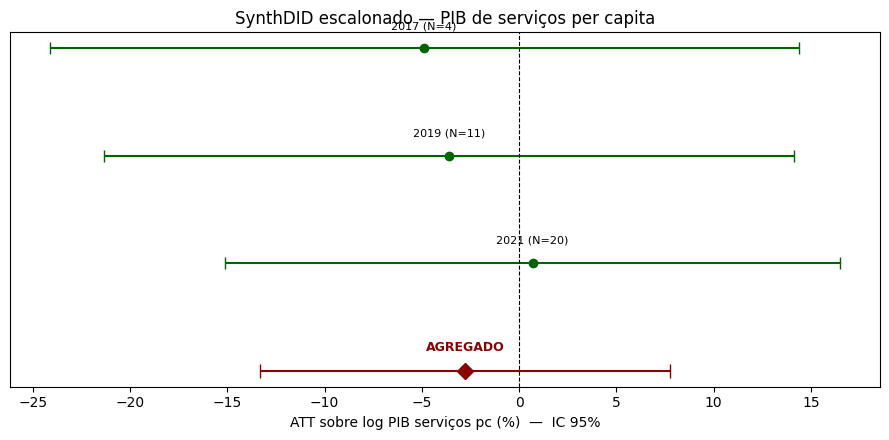

In [160]:
# Forest plot — serviços
_rs2 = [r for r in res_e2 if r is not None]
_y2 = np.arange(len(_rs2), 0, -1)

plt.figure(figsize=(9, 4.5))
for yi, r in zip(_y2, _rs2):
    att, se = r["att_sdid"] * 100, r["se_sdid"] * 100
    plt.errorbar(att, yi, xerr=1.96 * se, fmt="o", color="darkgreen", capsize=4)
    plt.text(att, yi + 0.18, f"{r['coorte']} (N={r['n_tratados']})",
             ha="center", fontsize=8)
plt.errorbar(att_agg2 * 100, 0, xerr=1.96 * se_agg2 * 100,
             fmt="D", color="darkred", capsize=5, markersize=8)
plt.text(att_agg2 * 100, 0.18, "AGREGADO", ha="center", fontsize=9,
         fontweight="bold", color="darkred")
plt.axvline(0, color="black", lw=0.8, ls="--")
plt.yticks([])
plt.xlabel("ATT sobre log PIB serviços pc (%)  —  IC 95%")
plt.title("SynthDID escalonado — PIB de serviços per capita")
plt.tight_layout(); plt.show()